# Photometry Jupyter Notebook

## Imports

In [173]:
import os
os.environ['BOKEH_ALLOW_WS_ORIGIN'] = ("1p28kn9d2v74i6ilhivhds70odo8uta4sugfufmvcsmi64u4r81g")
print("BOKEH_ALLOW_WS_ORIGIN =", os.environ.get('BOKEH_ALLOW_WS_ORIGIN'))

from astropy.io import fits
from astropy.time import Time
from astropy.wcs import WCS
import astropy.units as u
from astropy.coordinates import SkyCoord

import photutils
from photutils.psf import fit_2dgaussian
from photutils.centroids import centroid_2dg
from photutils.aperture import aperture_photometry, CircularAperture, CircularAnnulus
from astroquery.jplhorizons import Horizons

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.patches import Ellipse

import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar
from scipy.optimize import curve_fit

from bokeh.io import output_notebook, show
from bokeh.plotting import figure
from bokeh.models import HoverTool
output_notebook()

from astroquery.simbad import Simbad

import warnings
warnings.filterwarnings('ignore')

BOKEH_ALLOW_WS_ORIGIN = 1p28kn9d2v74i6ilhivhds70odo8uta4sugfufmvcsmi64u4r81g


Loading BokehJS ...

## Configuration

In [2]:
# Plotting parameters

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['legend.frameon'] = True
plt.rcParams['savefig.dpi'] = 400
plt.rcParams['figure.dpi'] = 130

In [3]:
# Directory containing reduced FITS files
direc = 'C:/Users/Matylda/Documents/TGP'  # UPDATE THIS PATH

# Image codes for each standard star
codes1 = [167861, 167863, 167866, 167868, 167869, 167870, 167871, 167872, 167874, 167875, 167876, 167877]
codes2 = [167879, 167880, 167881, 167882, 167885, 167886, 167887, 167888, 167889, 167890, 167905, 167906]
codes3 = [167891, 167892, 167893, 167894, 167895, 167896, 167897, 167899, 167900, 167901, 167902, 167903, 167904]

# Image codes for asteroid observations
asteroid_codes = [167137, 167140, 167147, 167148, 167149, 167150, 167152, 167153, 167154, 167155, 167156, 167158, 167159, 167160, 167161, 167162, 167163, 167164, 167165, 167166, 167167, 167168]

# Filter mapping
filter_map = {
    'R': ['r', 'red', 'R'],
    'V': ['v', 'V'],
    'B': ['b', 'blue', 'B'],
    'I': ['i', 'I']
}

# Standard star RA/Dec coordinates (hours, degrees)
# Standard Star 1: RA = 20h 30m 03.4s, Dec = 39° 15' 21"
ss1_ra = (20 + 30/60 + 3.4/3600) * 15  # Convert to degrees
ss1_dec = 39 + 15/60 + 21/3600

# Standard Star 2: RA = 1h 52m 4.29s, Dec = 47° 1' 47.4"
ss2_ra = (1 + 52/60 + 4.29/3600) * 15
ss2_dec = 47 + 1/60 + 47.4/3600

# Standard Star 3: RA = 3h 44m 7s, Dec = 45° 6' 0.2"
ss3_ra = (3 + 44/60 + 7/3600) * 15
ss3_dec = 45 + 6/60 + 0.2/3600

# Asteroid information
asteroid_name = "Belgica"  # UPDATE THIS
observatory_code = "Z63"   # PIRATE observatory code

# Centroid refinement radius (pixels)
centroid_radius_ss1 = 35
centroid_radius_ss2 = 25
centroid_radius_ss3 = 35
centroid_radius_asteroid = 10

## Utility Functions

In [4]:
def snr(data, ap, an):
    """
    Calculate signal-to-noise ratio for aperture photometry.
    
    Parameters:
    -----------
    data : array
        Image data
    ap : CircularAperture
        Aperture for photometry
    an : CircularAnnulus
        Annulus for sky background estimation
    
    Returns:
    --------
    float : Signal-to-noise ratio
    """
    phot = aperture_photometry(data, ap)
    flux_ap = phot['aperture_sum'][0]

    annulus_masks = an.to_mask(method='center')
    annulus_data = annulus_masks.multiply(data)
    sky_pixels = annulus_data[annulus_masks.data > 0]
    sky_mean = np.mean(sky_pixels)
    sky_std = np.std(sky_pixels)

    n_pix = ap.area
    flux = flux_ap - sky_mean * n_pix

    gain = 1.39
    flux_e = flux * gain
    sigma_sky_e = sky_std * gain
    noise = np.sqrt(flux_e + n_pix * sigma_sky_e**2)

    return flux_e / noise

def normalize_filter_name(filter_str, filter_map):
    """
    Normalize filter name to standard single-letter format.
    
    Parameters:
    -----------
    filter_str : str
        Filter name from FITS header
    filter_map : dict
        Mapping of filter variations to standard names
    
    Returns:
    --------
    str : Normalized filter name
    """
    for standard, variants in filter_map.items():
        if filter_str in variants:
            return standard
    return filter_str

def get_airmass(header):
    """
    Extract airmass from FITS header, calculating if necessary.
    
    Parameters:
    -----------
    header : astropy.io.fits.Header
        FITS header
    
    Returns:
    --------
    float : Airmass value
    """
    if 'AIRMASS' in header:
        return header['AIRMASS']
    elif 'ALTITUDE' in header:
        alt = header['ALTITUDE']
        if float(alt) > 0:
            zenith = 90 - alt
            return 1.0 / np.cos(np.radians(zenith))
    return 1.0  # Default if can't determine

def flux_to_mag(norm_flux):
    """
    Convert normalized flux to instrumental magnitude.
    
    Parameters:
    -----------
    norm_flux : float
        Flux normalized by exposure time
    
    Returns:
    --------
    float : Instrumental magnitude
    """
    return -2.5 * np.log10(norm_flux)

def error_in_mag(standardFlux, skyFlux):
    """
    Calculate magnitude error from photon statistics.
    
    Parameters:
    -----------
    standardFlux : float
        Source flux
    skyFlux : float
        Sky background flux
    
    Returns:
    --------
    float : Magnitude error
    """
    C = standardFlux
    dC = np.sqrt(standardFlux + skyFlux)
    return (-2.5 / np.log(10)) * (dC / C)

## Location Finding Functions

These functions find and refine the pixel coordinates of stars and asteroids using:
1. WCS transformation from RA/Dec (or JPL Horizons for asteroids)
2. 2D Gaussian centroid refinement

In [5]:
def find_star_locations(codes, ra, dec, data_dir, ref_code=None, centroid_radius=25, visualize=True):
    """
    Find and refine star locations using WCS and centroid refinement.
    
    Parameters:
    -----------
    codes : list
        List of image codes
    ra : float
        Right ascension in degrees
    dec : float
        Declination in degrees
    data_dir : str
        Directory containing FITS files
    ref_code : int, optional
        Reference image code for missing WCS headers
    centroid_radius : int
        Radius for centroid cutout in pixels
    visualize : bool
        Whether to display visualization
    
    Returns:
    --------
    tuple : (data, locations, headers)
        - data: list of image arrays
        - locations: list of (x, y) refined pixel coordinates
        - headers: list of FITS headers
    """
    
    # Load reference WCS if provided
    ref_wcs = None
    if ref_code is not None:
        with fits.open(f'{data_dir}/{ref_code}.fits') as ref:
            ref_hdr = ref[0].header.copy()
            ref_wcs = WCS(ref_hdr)
    
    # First pass: get approximate locations
    data = []
    locs_approx = []
    hdrs = []
    
    for c in codes:
        with fits.open(f'{data_dir}/{c}.fits') as file:
            hdr = file[0].header.copy()
            
            # If CRPIX is missing, copy WCS from reference
            if 'CRPIX1' not in hdr or 'CRPIX2' not in hdr:
                hdr.update(ref_wcs.to_header())
            
            # Correct for cropping the raw data
            hdr['CRPIX1'] -= 21
            hdr['CRPIX2'] -= 21
            wcs = WCS(hdr)
            
            # Convert RA/Dec to pixel coordinates
            px, py = wcs.world_to_pixel_values(ra, dec)
            
            image = file[0].data
            data.append(image)
            locs_approx.append((px, py))
            hdrs.append(hdr)
    
    # Second pass: refine locations using 2D Gaussian centroid
    r = centroid_radius
    locs_refined = []
    
    if visualize:
        n_images = len(data)
        ncols = min(4, n_images)
        nrows = (n_images + ncols - 1) // ncols
        fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
        if n_images == 1:
            axs = [axs]
        else:
            axs = axs.flatten() if nrows > 1 else axs
    
    for i, (d, l) in enumerate(zip(data, locs_approx)):
        x0, y0 = int(np.round(l[0])), int(np.round(l[1]))
        
        # Extract cutout around approximate location
        cutout = d[y0-r:y0+r+1, x0-r:x0+r+1]
        
        # Find centroid in cutout
        x_c, y_c = centroid_2dg(cutout)
        
        # Convert back to full image coordinates
        x_refined = x0 - r + x_c
        y_refined = y0 - r + y_c
        
        locs_refined.append((x_refined, y_refined))
        
        if visualize:
            vn, vx = np.percentile(d, [5, 99])
            axs[i].imshow(d, cmap="gray", vmin=vn, vmax=vx)
            axs[i].add_patch(Circle((x_refined, y_refined), radius=10, 
                                   edgecolor="red", facecolor="none", linewidth=2))
            axs[i].add_patch(Circle((x0, y0), radius=10, 
                                   edgecolor="blue", facecolor="none", linewidth=2))
            axs[i].set_xlim(x_refined-25, x_refined+25)
            axs[i].set_ylim(y_refined-25, y_refined+25)
            axs[i].set_title(f'Image {codes[i]}')
    
    if visualize:
        # Hide unused subplots
        for i in range(len(data), len(axs)):
            axs[i].axis('off')
        fig.tight_layout()
        plt.show()
    
    return data, locs_refined, hdrs

def find_asteroid_locations(codes, asteroid_name, observatory_code, data_dirs, 
                           centroid_radius=10, visualize=True):
    """
    Find and refine asteroid locations using JPL Horizons ephemeris.
    
    Parameters:
    -----------
    codes : list
        List of image codes
    asteroid_name : str
        Name of the asteroid
    observatory_code : str
        IAU observatory code
    data_dirs : dict
        Dictionary mapping special codes to alternate directories
    centroid_radius : int
        Radius for centroid cutout in pixels
    visualize : bool
        Whether to display visualization
    
    Returns:
    --------
    tuple : (data, locations, headers)
        - data: list of image arrays
        - locations: list of (x, y) refined pixel coordinates
        - headers: list of FITS headers
    """
    # First pass: get approximate locations using Horizons
    data = []
    locs_approx = []
    hdrs = []
    
    for c in codes:
        # Determine which directory to use
        data_dir = data_dirs.get(c, data_dirs['default'])
        
        with fits.open(f'{data_dir}/{c}.fits') as file:
            hdr = file[0].header.copy()
            
            # Query JPL Horizons for ephemeris
            obs_time = Time(hdr["DATE-OBS"], format="isot", scale="utc")
            obj = Horizons(id=asteroid_name, location=observatory_code, epochs=obs_time.jd)
            eph = obj.ephemerides()
            ra = eph["RA"][0]
            dec = eph["DEC"][0]
            
            # Correct for cropping the raw data
            hdr['CRPIX1'] -= 21
            hdr['CRPIX2'] -= 21
            wcs = WCS(hdr)
            
            # Convert RA/Dec to pixel coordinates
            px, py = wcs.world_to_pixel_values(ra, dec)
            
            image = file[0].data
            data.append(image)
            locs_approx.append((px, py))
            hdrs.append(hdr)
    
    # Second pass: refine locations using 2D Gaussian centroid
    r = centroid_radius
    locs_refined = []
    
    if visualize:
        n_images = len(data)
        ncols = min(5, n_images)
        nrows = (n_images + ncols - 1) // ncols
        fig, axs = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
        if n_images == 1:
            axs = [axs]
        else:
            axs = axs.flatten() if nrows > 1 else axs
    
    for i, (d, l) in enumerate(zip(data, locs_approx)):
        x0, y0 = int(np.round(l[0])), int(np.round(l[1]))
        
        # Extract cutout around approximate location
        cutout = d[y0-r:y0+r+1, x0-r:x0+r+1]
        
        # Find centroid in cutout
        x_c, y_c = centroid_2dg(cutout)
        
        # Convert back to full image coordinates
        x_refined = x0 - r + x_c
        y_refined = y0 - r + y_c
        
        locs_refined.append((x_refined, y_refined))
        
        if visualize:
            vn, vx = np.percentile(d, [5, 99])
            axs[i].imshow(d, cmap="gray", vmin=vn, vmax=vx)
            axs[i].add_patch(Circle((x_refined, y_refined), radius=6, 
                                   edgecolor="red", facecolor="none", linewidth=2))
            axs[i].add_patch(Circle((x0, y0), radius=6, 
                                   edgecolor="blue", facecolor="none", linewidth=2))
            axs[i].set_xlim(x_refined-10, x_refined+10)
            axs[i].set_ylim(y_refined-10, y_refined+10)
            axs[i].set_title(f'{codes[i]}')
            axs[i].axis('off')
    
    if visualize:
        # Hide unused subplots
        for i in range(len(data), len(axs)):
            axs[i].axis('off')
        fig.tight_layout()
        plt.show()
    
    return data, locs_refined, hdrs

## Find Star and Asteroid Locations

Run this section to automatically find and refine all source locations.

Finding Standard Star 1 locations...


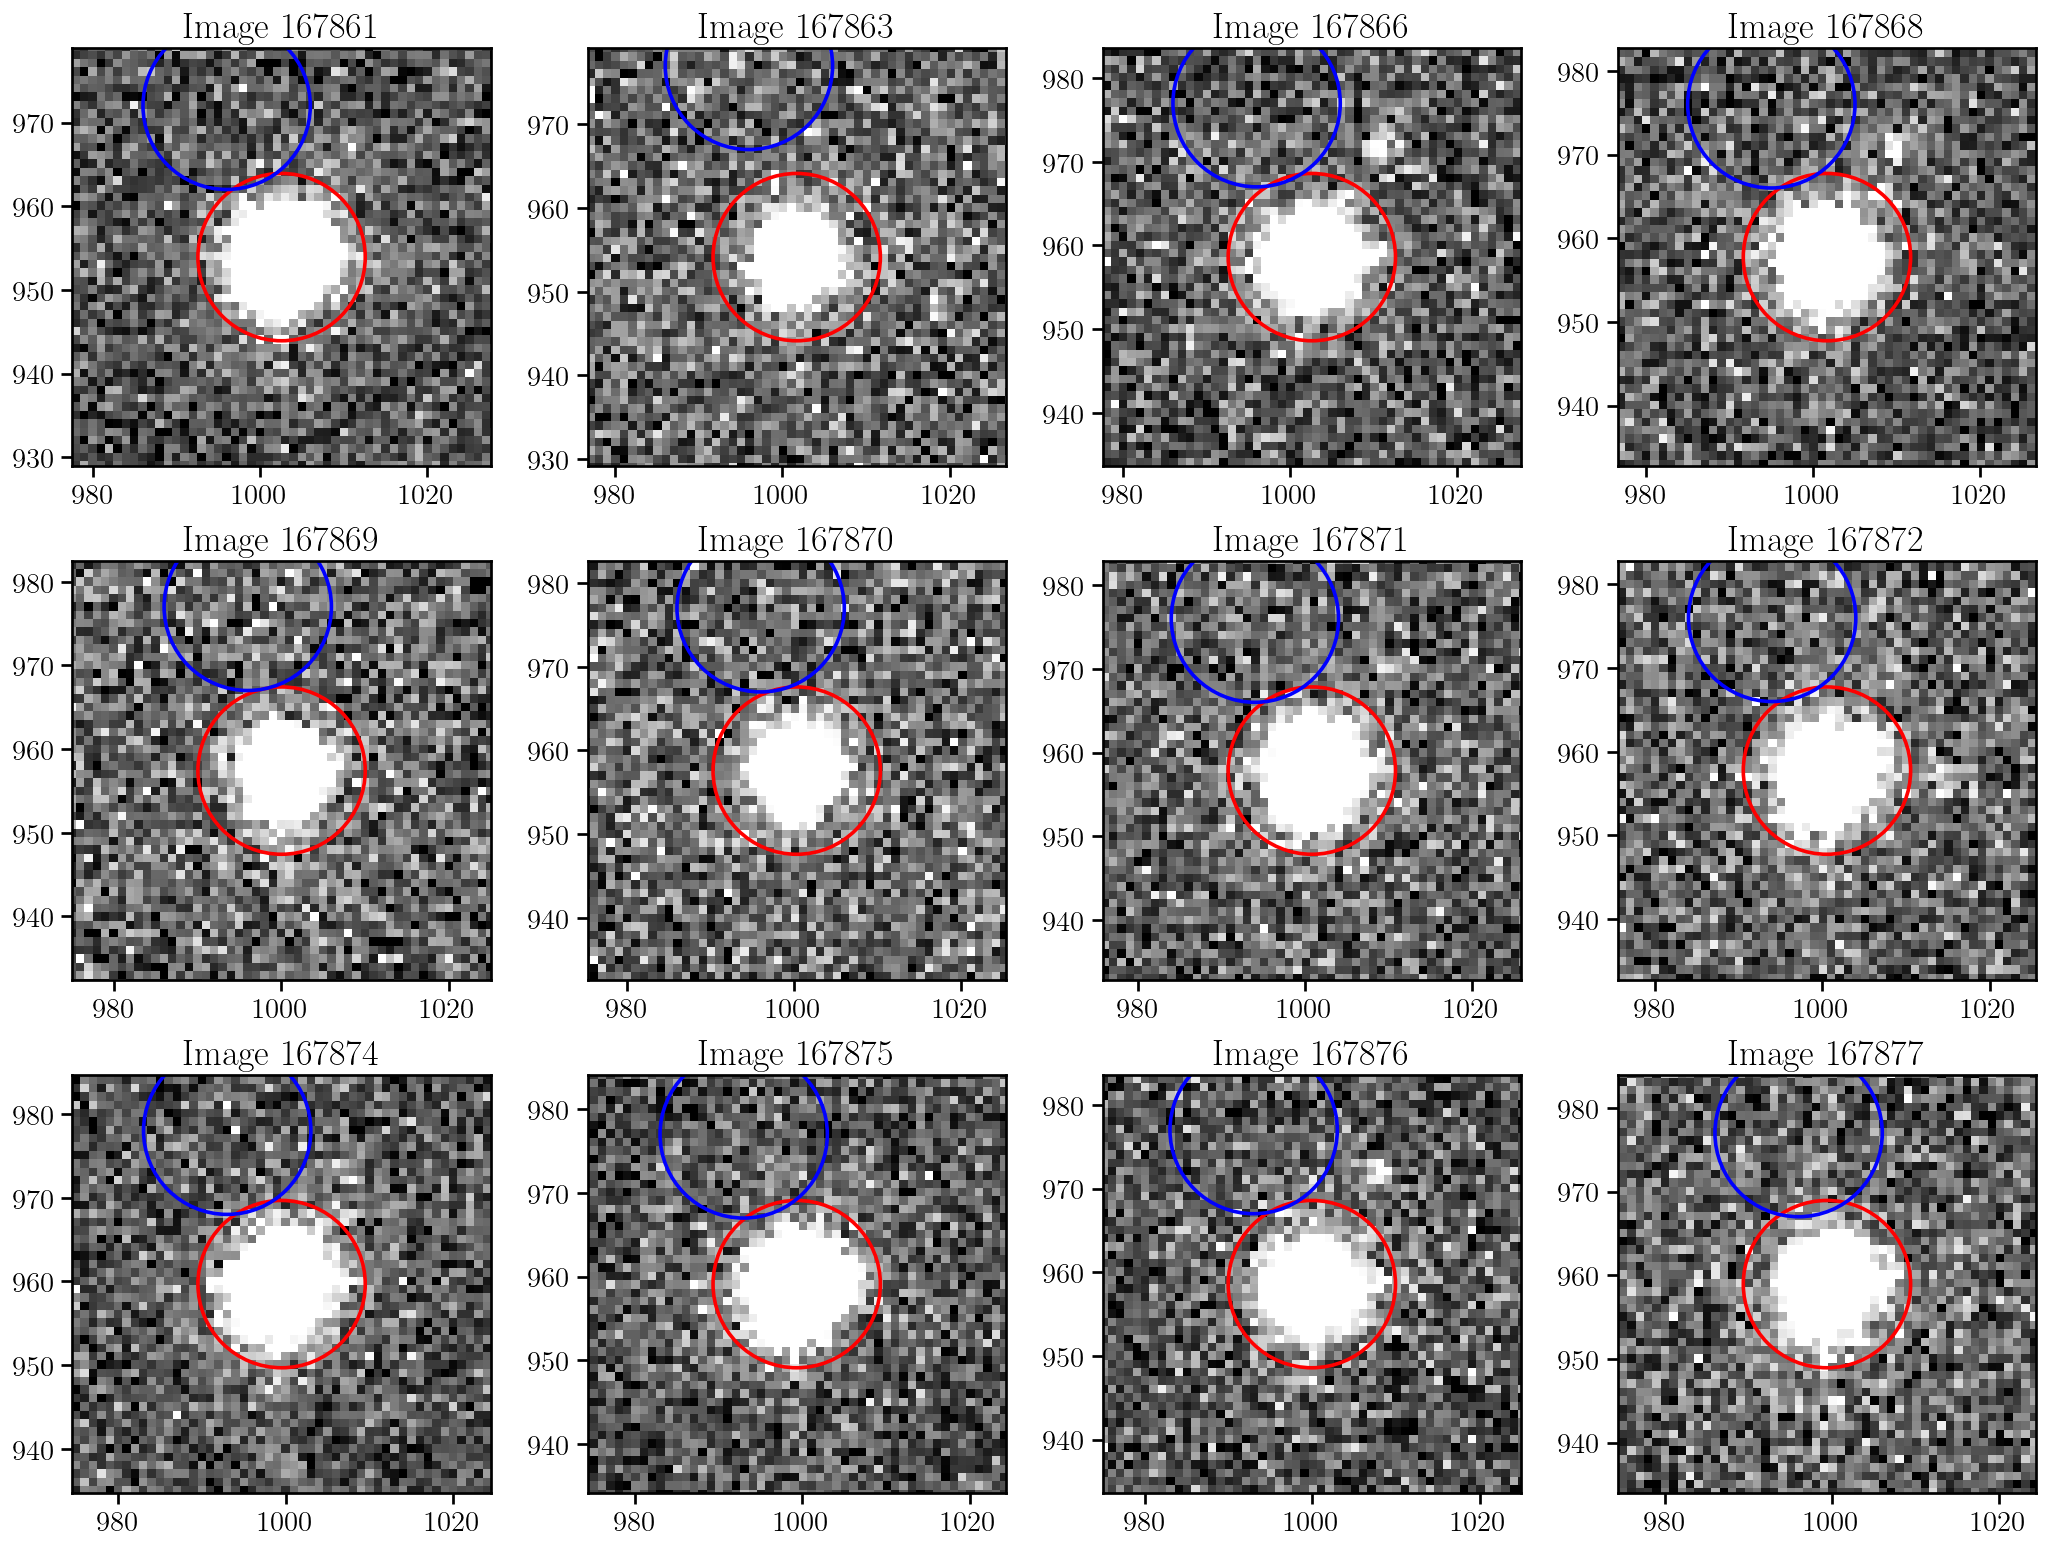

Found 12 locations for Standard Star 1


In [6]:
print("Finding Standard Star 1 locations...")
data1, locs1, hdrs1 = find_star_locations(
    codes1, ss1_ra, ss1_dec, 
    f'{direc}/Reduced_data_day3',
    ref_code=167866,
    centroid_radius=centroid_radius_ss1,
    visualize=True
)
print(f"Found {len(locs1)} locations for Standard Star 1")

Finding Standard Star 2 locations...


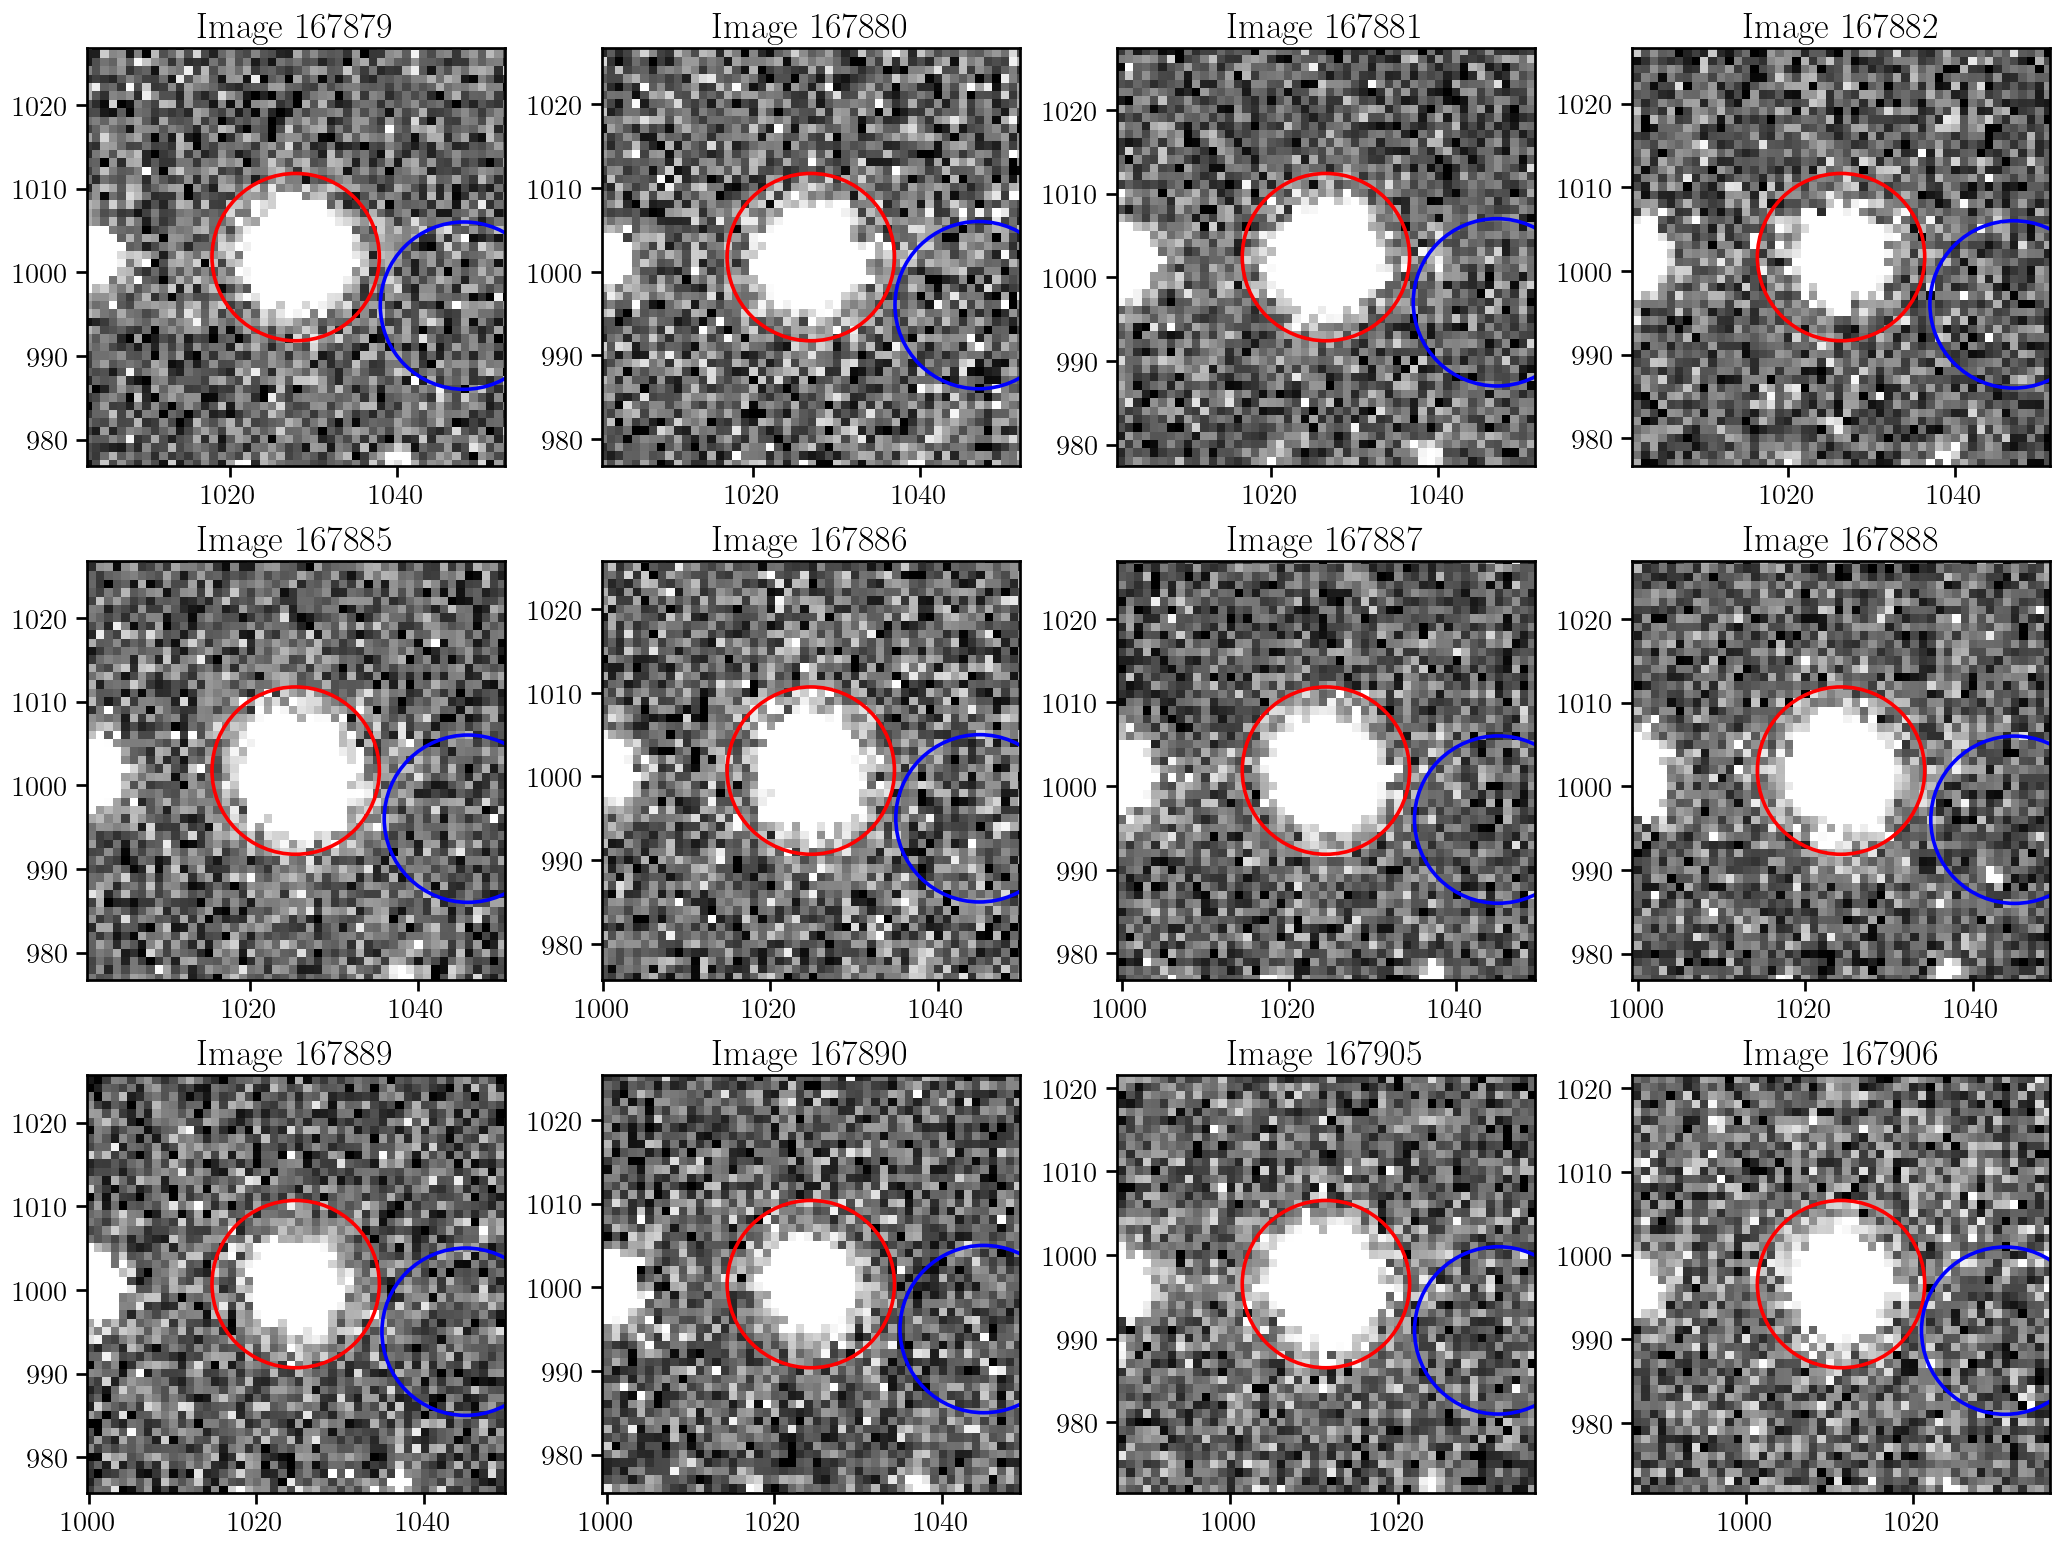

Found 12 locations for Standard Star 2


In [7]:
print("Finding Standard Star 2 locations...")
data2, locs2, hdrs2 = find_star_locations(
    codes2, ss2_ra, ss2_dec,
    f'{direc}/Reduced_data_day3',
    ref_code=167879,  # Reference image for missing WCS
    centroid_radius=centroid_radius_ss2,
    visualize=True
)
print(f"Found {len(locs2)} locations for Standard Star 2")

Finding Standard Star 3 locations...


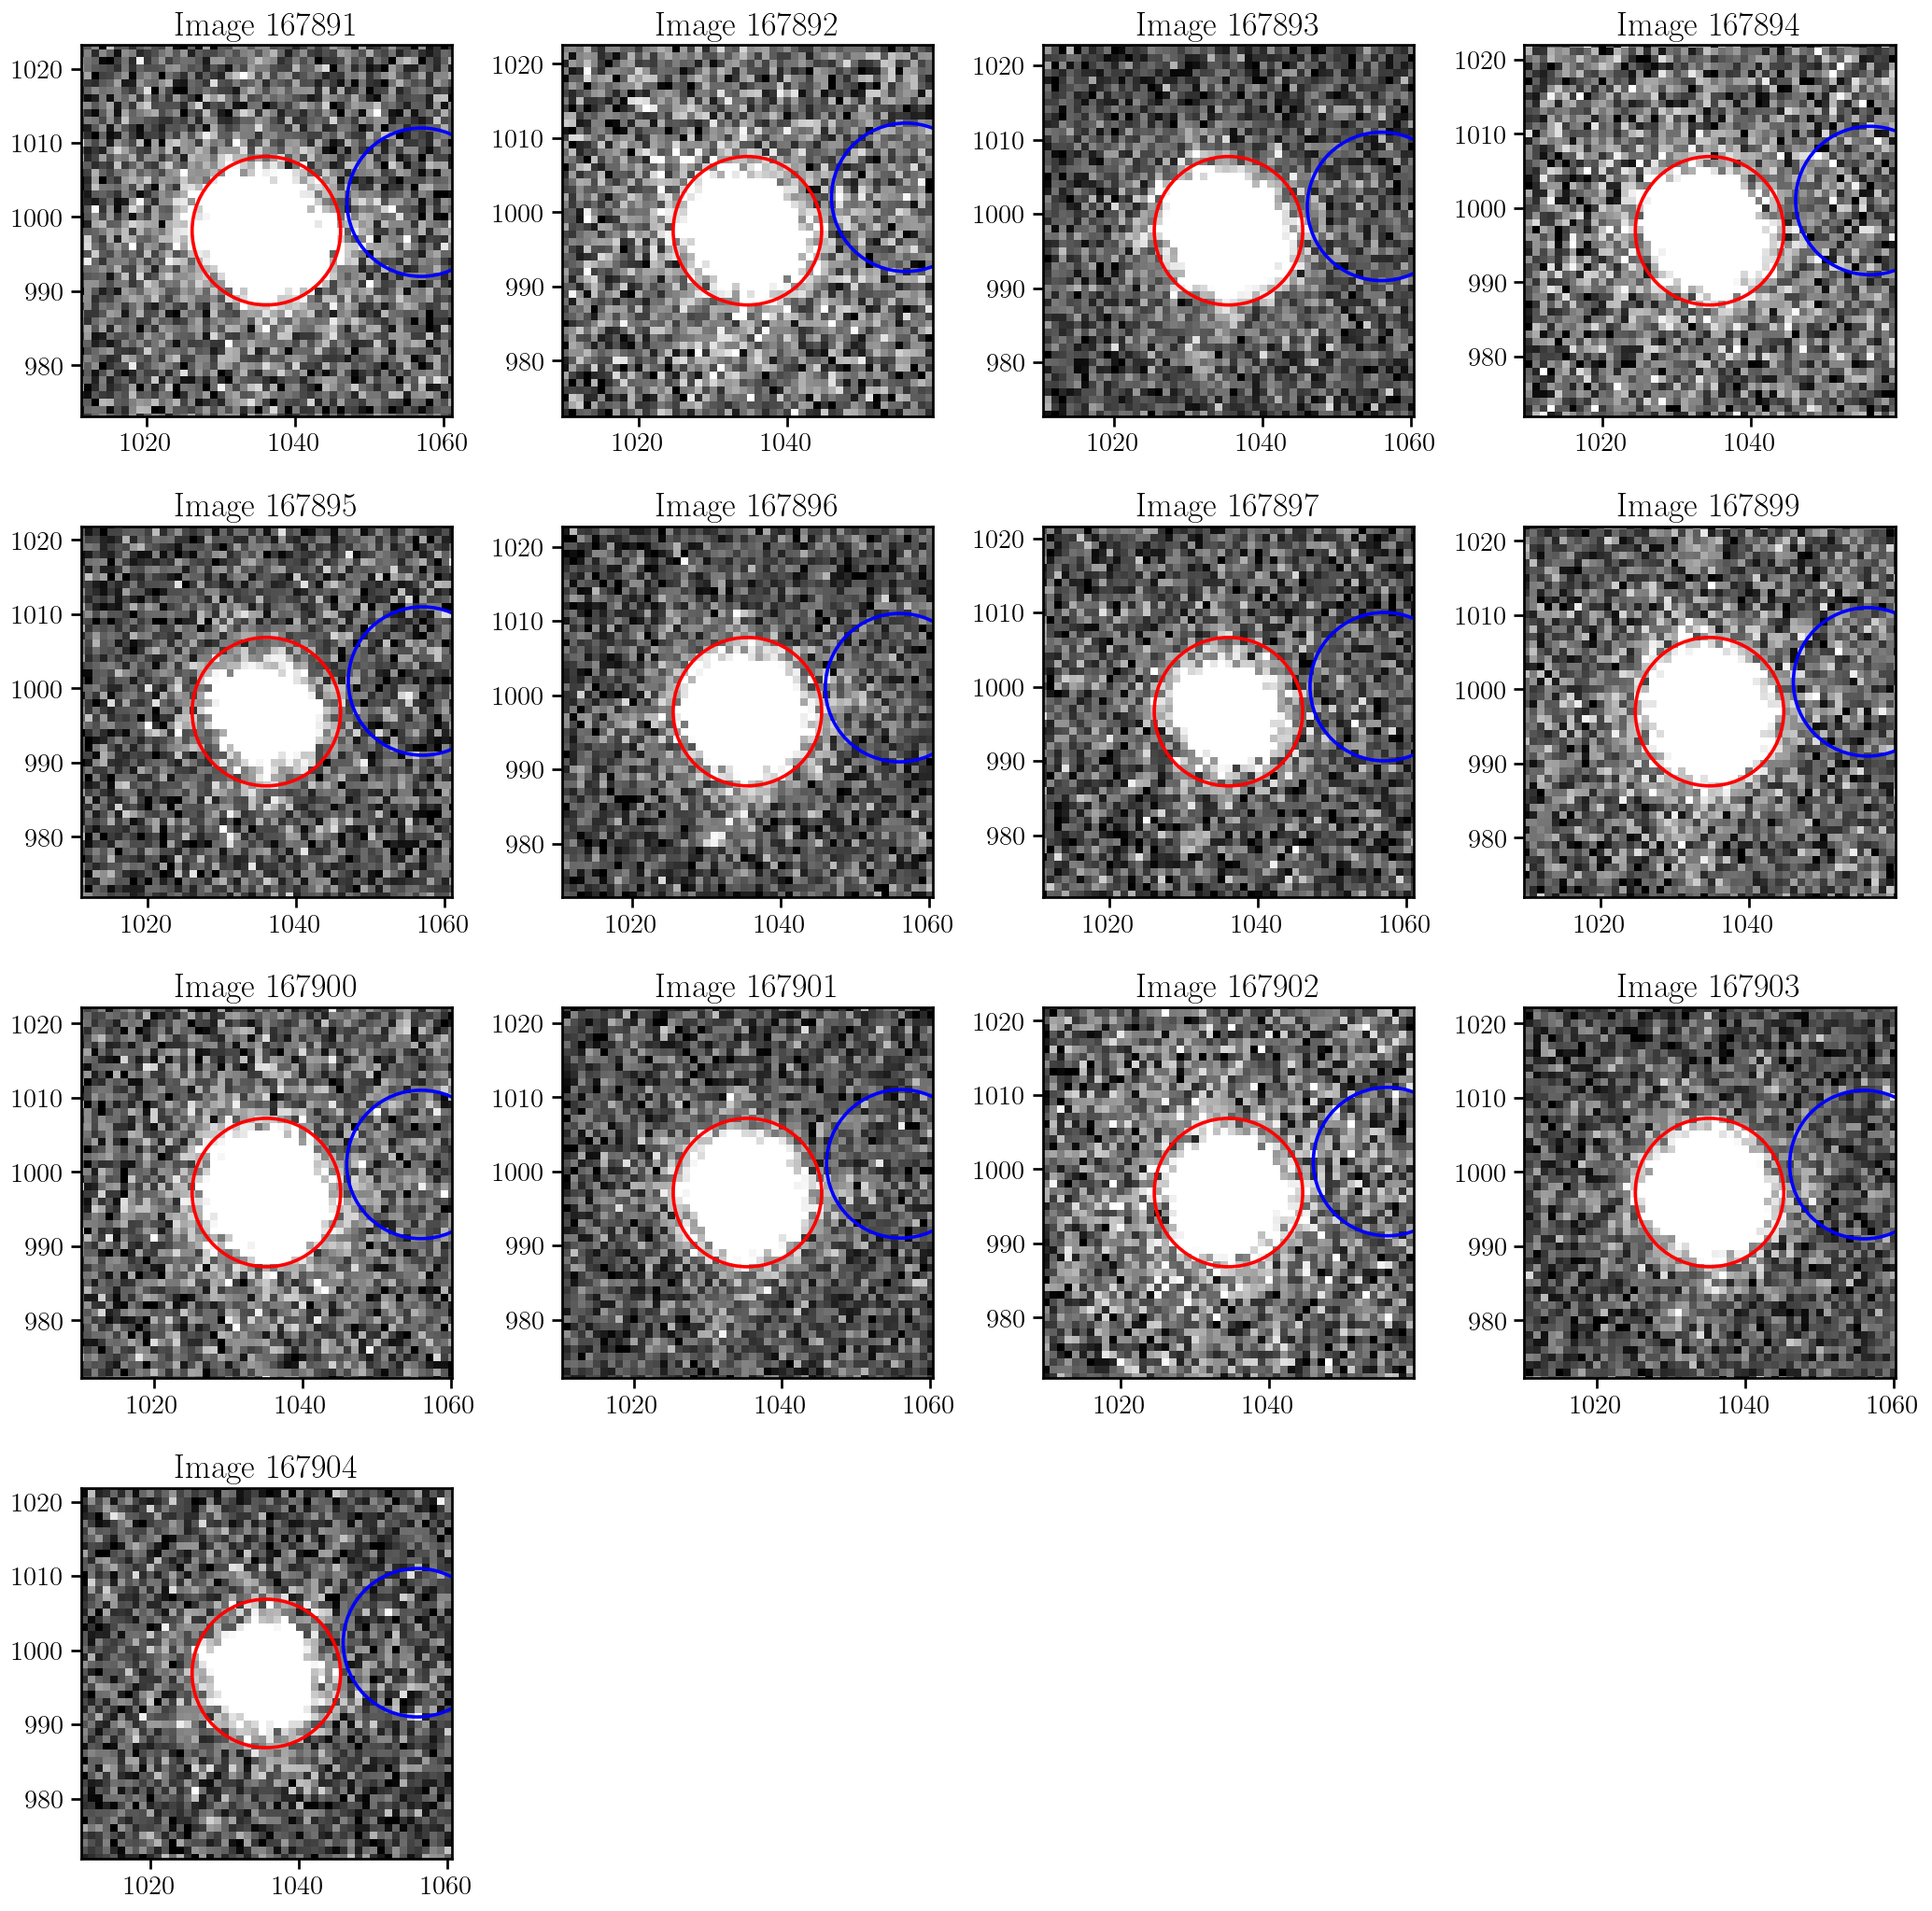

Found 13 locations for Standard Star 3


In [8]:
print("Finding Standard Star 3 locations...")
data3, locs3, hdrs3 = find_star_locations(
    codes3, ss3_ra, ss3_dec,
    f'{direc}/Reduced_data_day3',
    ref_code=167891,  # Reference image for missing WCS
    centroid_radius=centroid_radius_ss3,
    visualize=True
)
print(f"Found {len(locs3)} locations for Standard Star 3")

Finding Belgica locations using JPL Horizons...


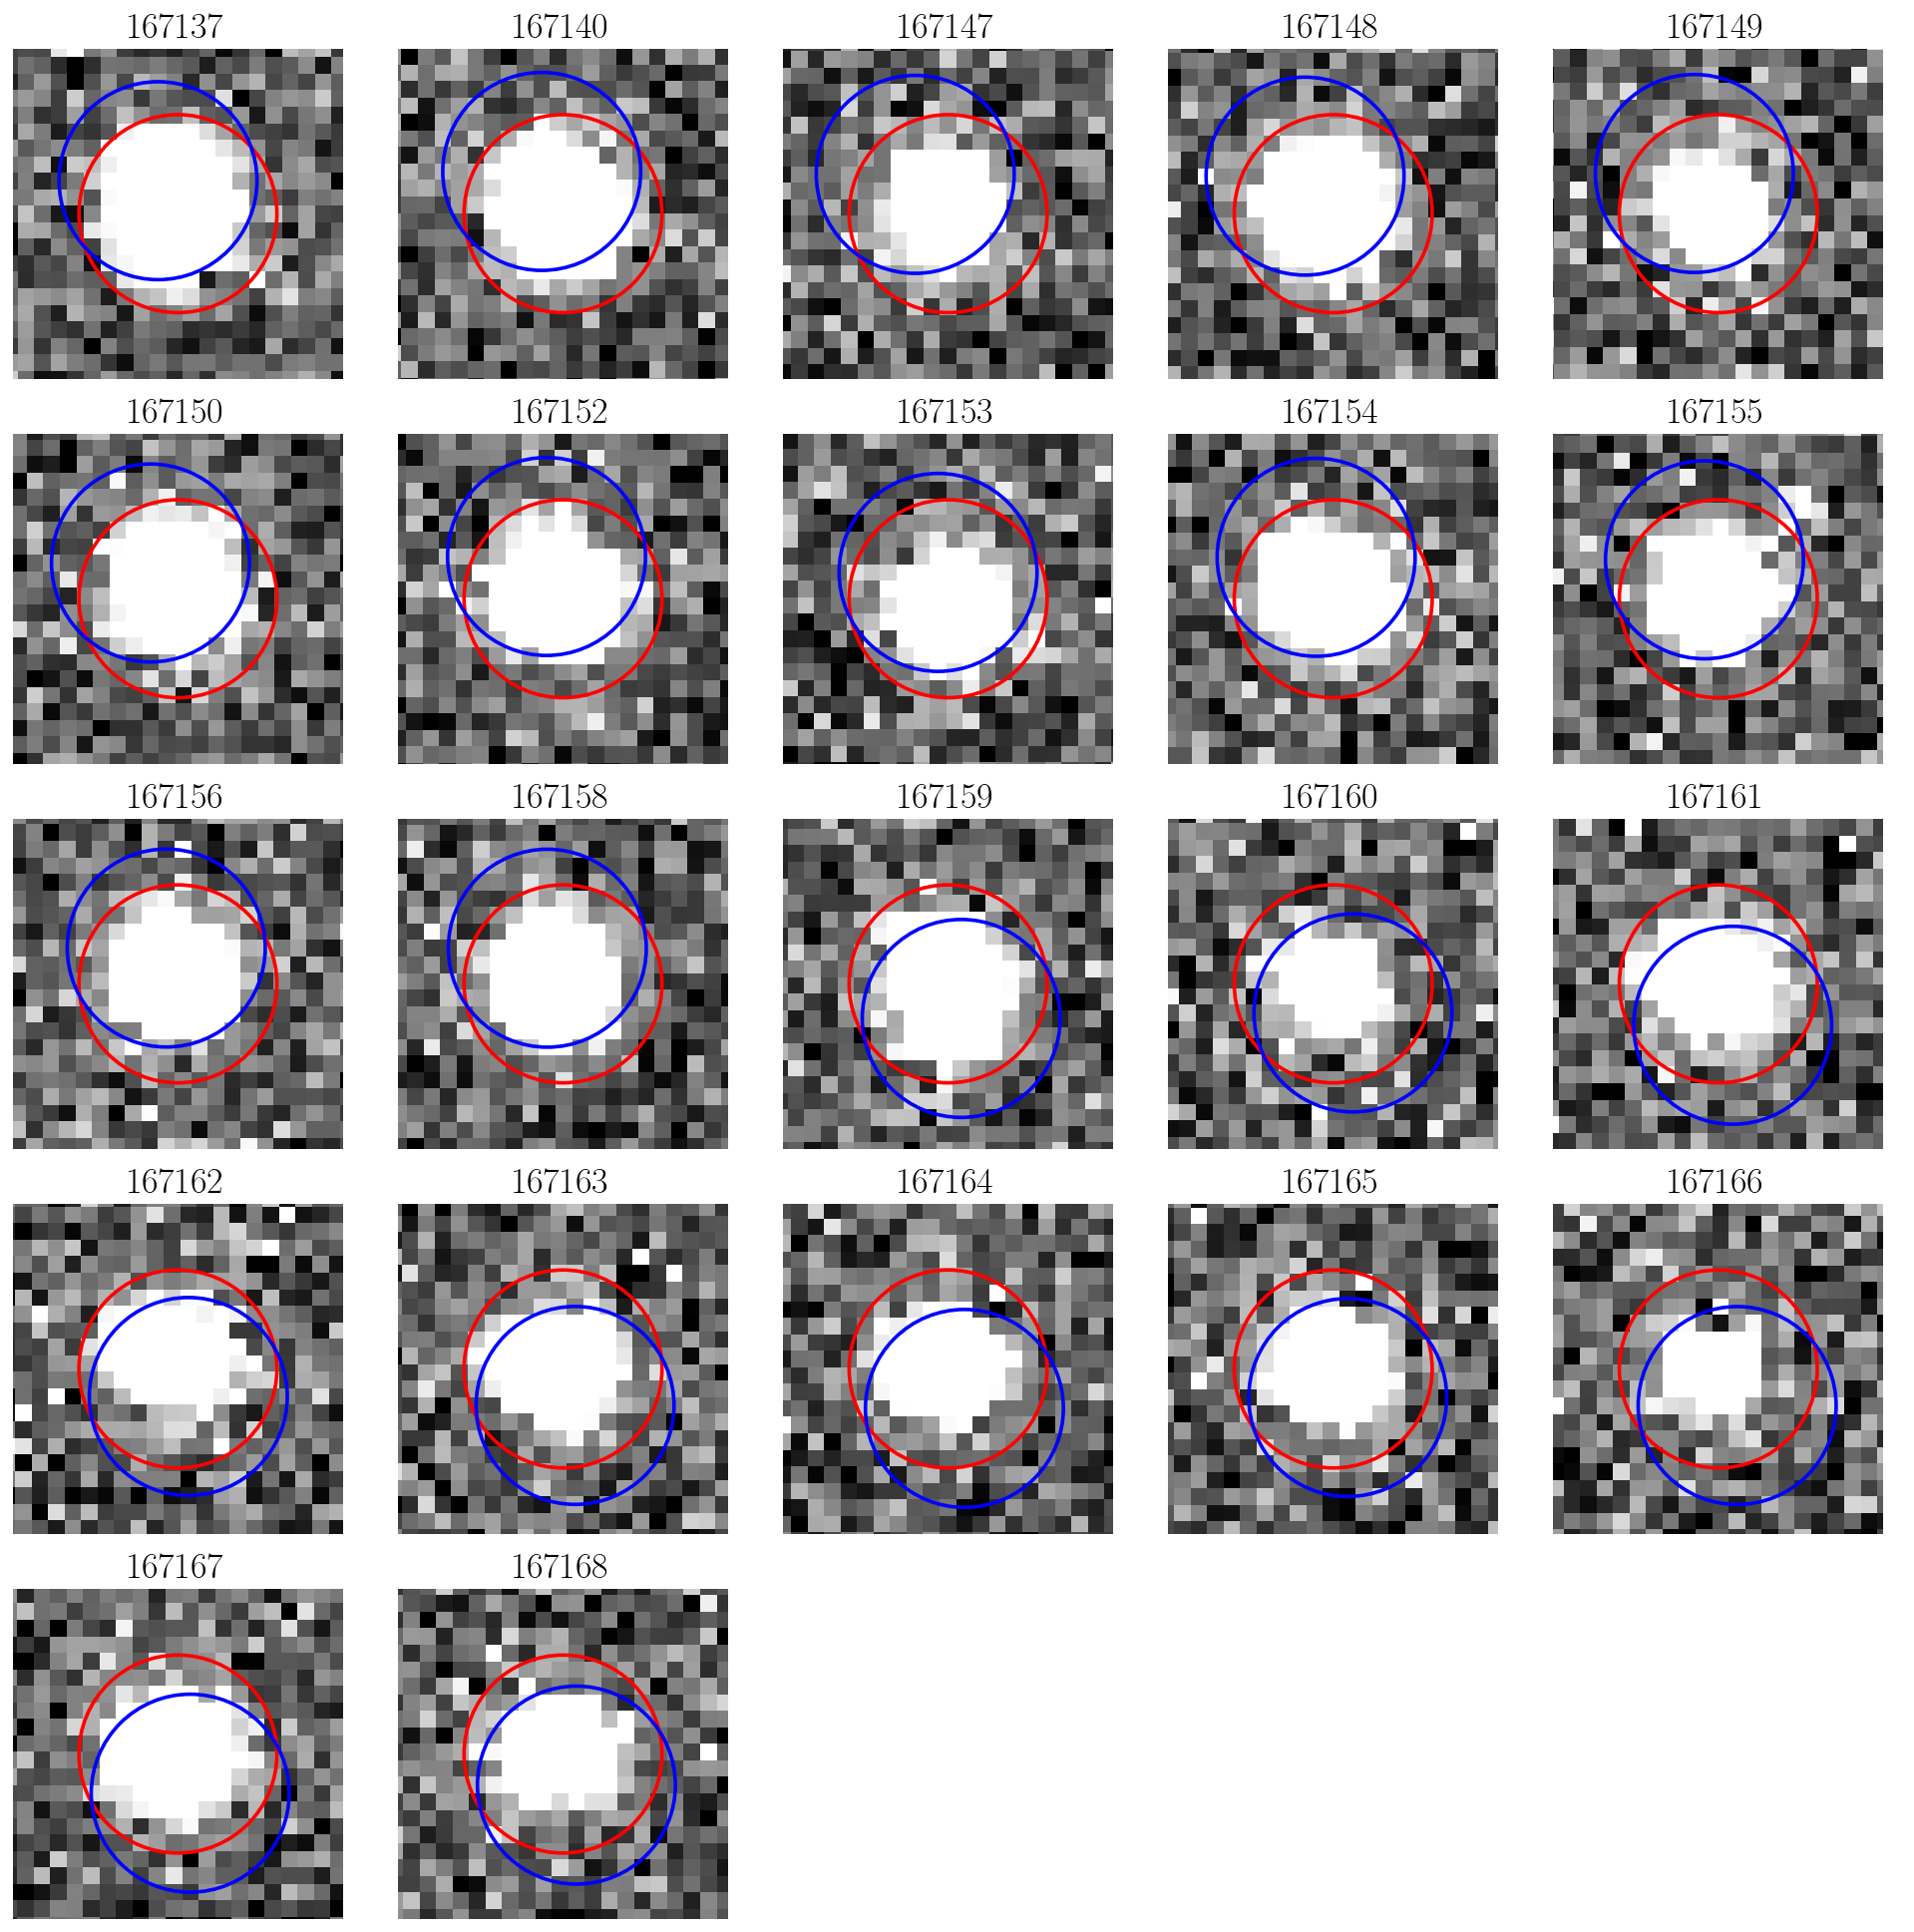

Found 22 locations for Belgica


In [61]:
print(f"Finding {asteroid_name} locations using JPL Horizons...")

# Define which images are in alternate directories
asteroid_data_dirs = {
    'default': f'{direc}/Reduced_data_day2',
    167153: f'{direc}/Reduced_data_I',
    167162: f'{direc}/Reduced_data_I',
    167168: f'{direc}/Reduced_data_I'
}

data_asteroid, locs_asteroid, hdrs_asteroid = find_asteroid_locations(
    asteroid_codes, asteroid_name, observatory_code,
    asteroid_data_dirs,
    centroid_radius=centroid_radius_asteroid,
    visualize=True
)
print(f"Found {len(locs_asteroid)} locations for {asteroid_name}")

## Aperture Optimization - REDUNDANT

In [62]:
"""def optimize_apertures(data, locations, title="Aperture Optimization"):

    n_images = len(data)
    ncols = min(4, n_images)
    nrows = (n_images + ncols - 1) // ncols
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    if n_images == 1:
        axs = [axs]
    else:
        axs = axs.flatten() if nrows > 1 else axs
    
    optimal_radii = []
    
    for i, (d, loc, ax) in enumerate(zip(data, locations, axs)):
        def ap_opt(r):
            if r <= 0:  # Safety check
                return 1e10
            an1 = 2 * r
            an2 = 3 * r
            ap = CircularAperture(loc, r=r)
            an = CircularAnnulus(loc, r_in=an1, r_out=an2)
            return -snr(d, ap, an)
        
        # Rough search
        aps = np.linspace(0.5, 20, 20)
        rough_peak = aps[np.argmax([-ap_opt(ap) for ap in aps])]
        
        # Fine optimization with safe bounds
        lower_bound = max(0.5, rough_peak - 2)  # Ensure lower bound is positive
        upper_bound = rough_peak + 2
        res = minimize_scalar(ap_opt, bounds=(lower_bound, upper_bound), method='bounded')
        optimal_radii.append(res.x)
        
        # Plot
        ax.plot(aps, [-ap_opt(ap) for ap in aps], c="k")
        ax.scatter(res.x, -res.fun, c="r", s=100, zorder=5)
        ax.set_title(f"r = {res.x:.2f} px\nSNR = {-res.fun:.1f}")
        ax.set_xlabel("Aperture radius (px)")
        ax.set_ylabel("SNR")
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(len(data), len(axs)):
        axs[i].axis('off')
    
    fig.suptitle(title, fontsize=14, y=1.00)
    fig.tight_layout()
    plt.show()
    
    return optimal_radii

print("Optimizing apertures for Standard Star 1...")
optims1 = optimize_apertures(data1, locs1, "Standard Star 1 - Aperture Optimization")

print("\nOptimizing apertures for Standard Star 2...")
optims2 = optimize_apertures(data2, locs2, "Standard Star 2 - Aperture Optimization")

print("\nOptimizing apertures for Standard Star 3...")
optims3 = optimize_apertures(data3, locs3, "Standard Star 3 - Aperture Optimization")

print(f"\nOptimizing apertures for {asteroid_name}...")
optims_asteroid = optimize_apertures(data_asteroid, locs_asteroid, f"{asteroid_name} - Aperture Optimization")"""

'def optimize_apertures(data, locations, title="Aperture Optimization"):\n\n    n_images = len(data)\n    ncols = min(4, n_images)\n    nrows = (n_images + ncols - 1) // ncols\n    \n    fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))\n    if n_images == 1:\n        axs = [axs]\n    else:\n        axs = axs.flatten() if nrows > 1 else axs\n    \n    optimal_radii = []\n    \n    for i, (d, loc, ax) in enumerate(zip(data, locations, axs)):\n        def ap_opt(r):\n            if r <= 0:  # Safety check\n                return 1e10\n            an1 = 2 * r\n            an2 = 3 * r\n            ap = CircularAperture(loc, r=r)\n            an = CircularAnnulus(loc, r_in=an1, r_out=an2)\n            return -snr(d, ap, an)\n        \n        # Rough search\n        aps = np.linspace(0.5, 20, 20)\n        rough_peak = aps[np.argmax([-ap_opt(ap) for ap in aps])]\n        \n        # Fine optimization with safe bounds\n        lower_bound = max(0.5, rough_peak - 2)  # Ensure l

## Set the apertures manually

In [ ]:
def plot_aperture(codes, data_dirs, locs, radius, centroid_radius=10):
    """
    Plot potential aperture radius overlaid on astronomical images.
    
    Parameters:
    -----------
    codes : list or array
        List of image codes/filenames (without .fits extension)
    data_dirs : dict, str, or array
        - dict: mapping codes to directories {code: dir, 'default': dir}
        - str: single directory for all images
        - array: array of directories (one per code)
    locs : list or array of tuples
        List of (x, y) approximate locations for each image
    radius : float
        Aperture radius to display in pixels
    centroid_radius : int, optional
        Radius for centroid refinement cutout in pixels (default: 10)
        
    Returns:
    --------
    list : Refined (x, y) locations after centroid fitting
    """
    from astropy.io import fits
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Circle
    from photutils.centroids import centroid_2dg
    
    # Convert codes to list if needed
    codes = list(codes) if not isinstance(codes, list) else codes
    
    # Handle different data_dirs formats
    if isinstance(data_dirs, dict):
        # Dictionary format: look up each code
        def get_dir(c):
            return data_dirs.get(c, data_dirs.get('default', '.'))
    elif isinstance(data_dirs, str):
        # Single string: use for all
        def get_dir(c):
            return data_dirs
    else:
        # Array format: use corresponding index
        data_dirs_list = list(data_dirs)
        def get_dir(c):
            idx = codes.index(c)
            return data_dirs_list[idx]
    
    # Load data
    data = []
    for c in codes:
        data_dir = get_dir(c)
        with fits.open(f'{data_dir}/{c}.fits') as file:
            data.append(file[0].data.copy())
    
    # Refine locations using 2D Gaussian centroid
    r = centroid_radius
    locs_refined = []
    
    for d, l in zip(data, locs):
        x0, y0 = int(np.round(l[0])), int(np.round(l[1]))
        
        # Extract cutout around approximate location
        cutout = d[y0-r:y0+r+1, x0-r:x0+r+1]
        
        # Find centroid in cutout
        x_c, y_c = centroid_2dg(cutout)
        
        # Convert back to full image coordinates
        x_refined = x0 - r + x_c
        y_refined = y0 - r + y_c
        
        locs_refined.append((x_refined, y_refined))
    
    # Create visualization
    n_images = len(data)
    ncols = min(5, n_images)
    nrows = (n_images + ncols - 1) // ncols
    fig, axs = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
    
    # Handle single or multiple subplots
    if n_images == 1:
        axs = [axs]
    elif nrows > 1:
        axs = axs.flatten()
    
    for i, (d, (x_refined, y_refined), (x0, y0)) in enumerate(zip(data, locs_refined, locs)):
        # Set intensity scaling
        vmin, vmax = np.percentile(d, [5, 99])
        
        # Display image
        axs[i].imshow(d, cmap="gray", vmin=vmin, vmax=vmax)
        
        # Plot refined centroid with aperture
        axs[i].add_patch(Circle((x_refined, y_refined), radius=radius, 
                               edgecolor="red", facecolor="none", linewidth=2, 
                               label='Aperture'))
        # Plot sky background inner centroid IMPORTANT: This is x2.5 times the aperture
        axs[i].add_patch(Circle((x_refined, y_refined), radius=2.5*radius, 
                               edgecolor="red", facecolor="none", linewidth=2, 
                               ls="dashed", label='rSkyInner'))
        # Plot sky background outer centroid IMPORTANT: This is x3 times the aperture!!
        axs[i].add_patch(Circle((x_refined, y_refined), radius=3*radius, 
                               edgecolor="red", facecolor="none", linewidth=2, 
                               ls="dotted", label='rSkyOuter'))
        
        # Mark refined centroid
        axs[i].plot(x_refined, y_refined, 'r+', markersize=10, markeredgewidth=1.5)
        
        # Set zoom around refined location
        zoom = max(radius * 2.5, 20)
        axs[i].set_xlim(x_refined - zoom, x_refined + zoom)
        axs[i].set_ylim(y_refined - zoom, y_refined + zoom)
        axs[i].set_title(f'{codes[i]}', fontsize=10)
        axs[i].axis('off')
        
        # Add legend to first subplot
        if i == 0:
            axs[i].legend(loc='upper right', fontsize=8)
    
    # Hide unused subplots
    for i in range(n_images, len(axs)):
        axs[i].axis('off')
    
    fig.suptitle(f'Aperture Preview (radius = {radius:.1f} px)', fontsize=12, y=0.98)
    fig.tight_layout()
    plt.show()
    
    return locs_refined

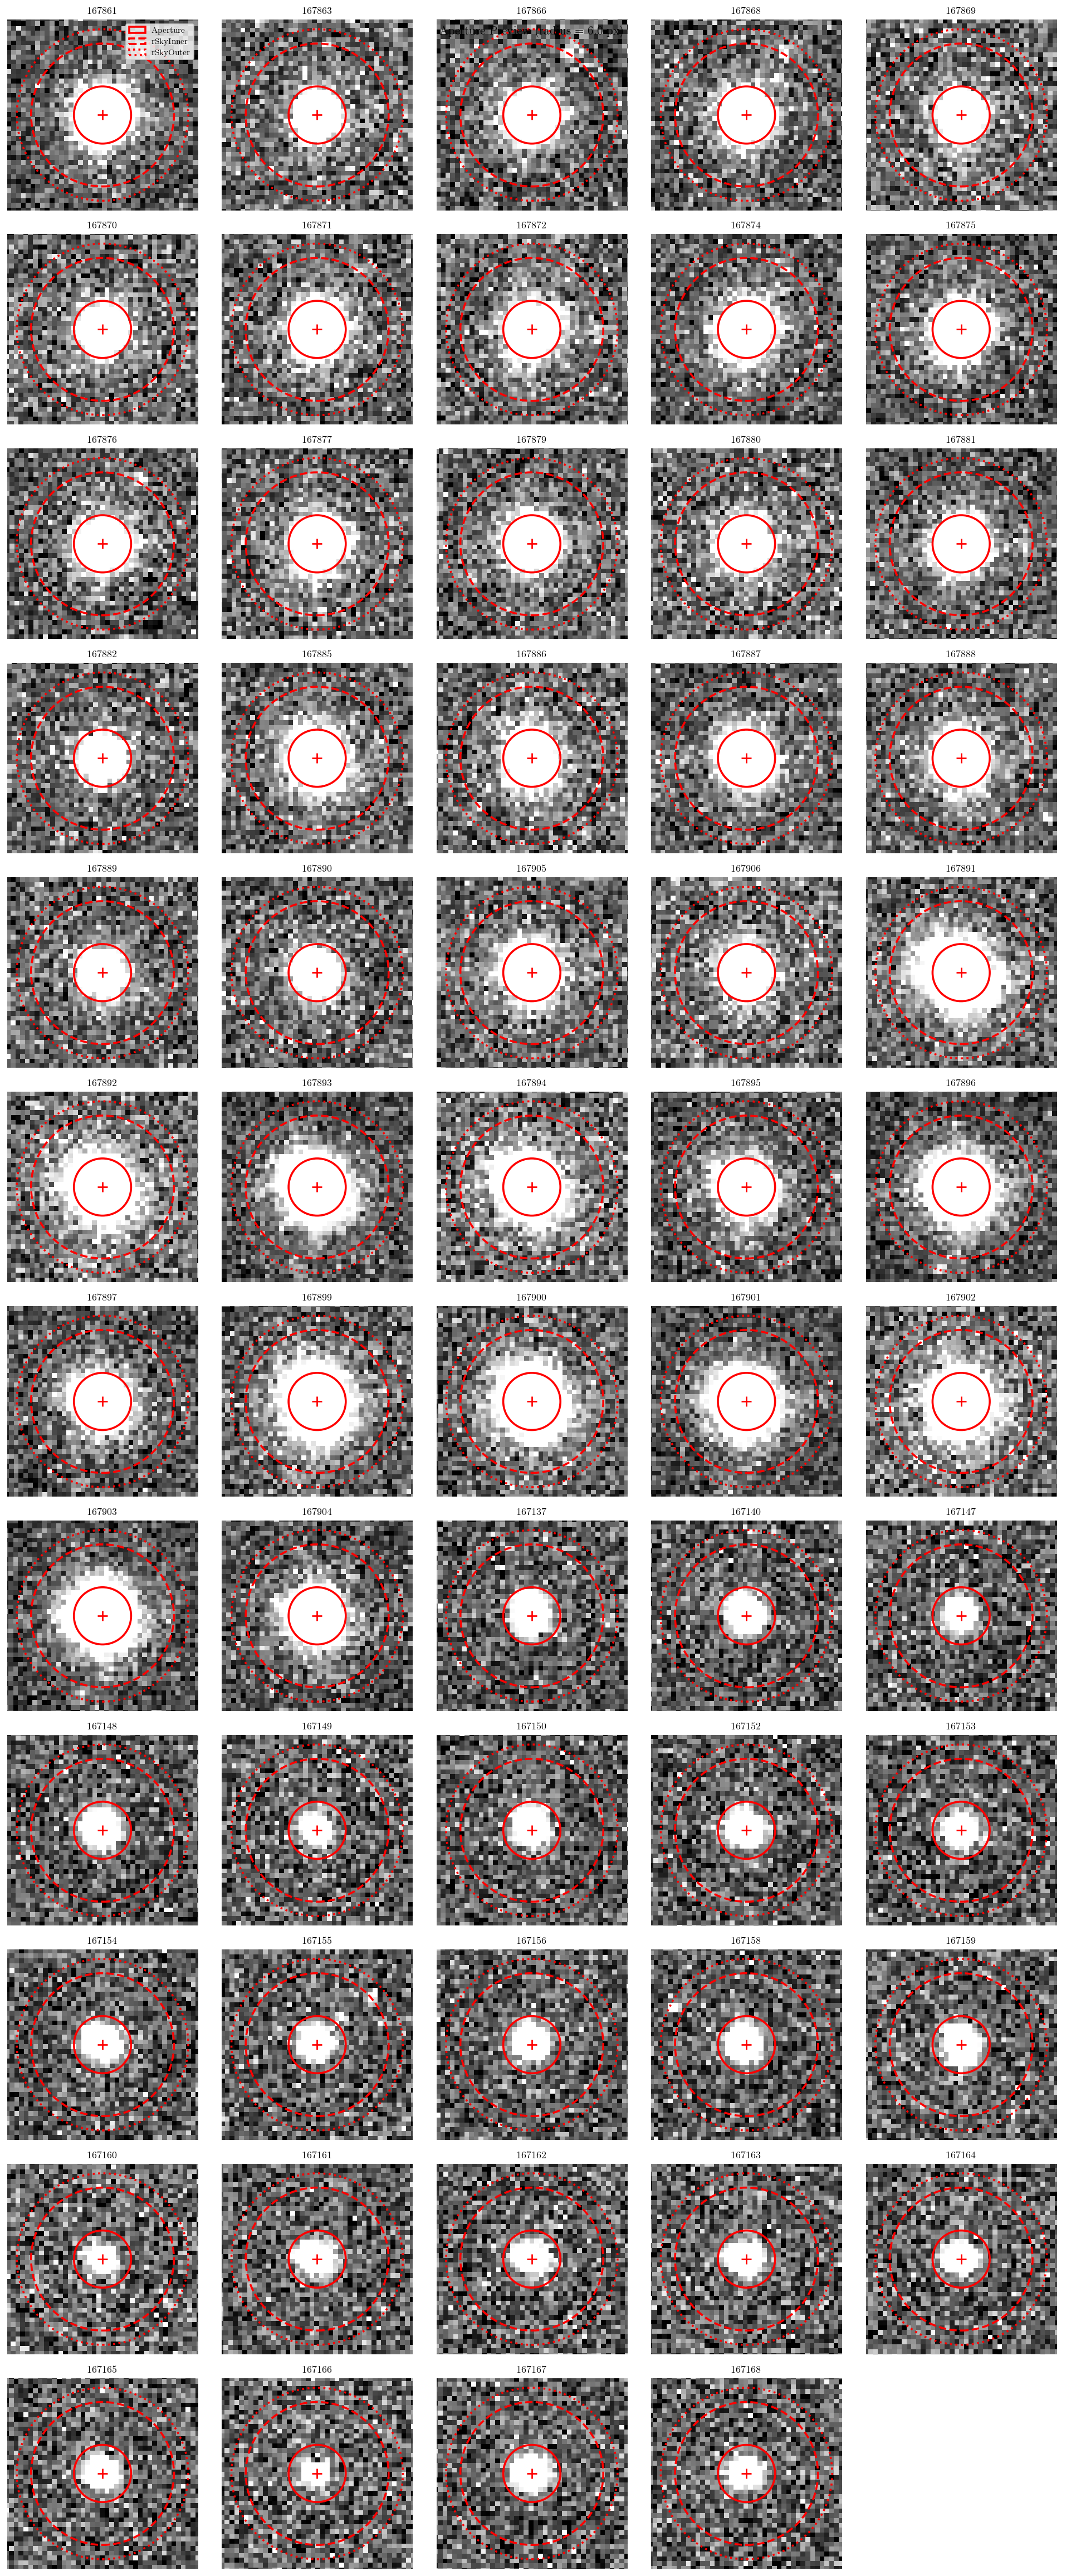

[(1002.6307170402034, 953.879186377531),
 (1001.549343643825, 954.1997777396988),
 (1002.6530997005248, 958.5781452298044),
 (1001.6754485042203, 957.7142912275118),
 (1000.4387621489561, 957.3674200462322),
 (1000.1358323664865, 957.8373811646862),
 (1000.9042249868082, 957.7491934165889),
 (1000.6156154146872, 957.6653478240663),
 (999.4962032184601, 959.6624985990578),
 (999.412509192917, 959.0404411990759),
 (1000.0152175443317, 958.5556604062136),
 (999.4371614936816, 958.8531741184217),
 (1028.041243928816, 1001.7661556782688),
 (1027.080343005464, 1001.5954218234554),
 (1026.6627440427762, 1002.3985245971861),
 (1026.5206923248409, 1001.853611090258),
 (1025.5260525207264, 1001.6246428634506),
 (1025.0894334333427, 1000.748941356237),
 (1024.5317521405152, 1001.8149928093695),
 (1024.3836560676395, 1001.8198994110886),
 (1024.7820773671624, 1000.6220763238033),
 (1024.5610837295246, 1000.4255119063819),
 (1011.61637080126, 996.3663373612985),
 (1011.4180798633317, 996.4571375419

In [69]:
# Plot all images

all_codes = np.concatenate((codes1, codes2, codes3, asteroid_codes))
all_locs = np.concatenate((locs1, locs2, locs3, locs_asteroid))

# Create directory array
ss_dir = f'{direc}/Reduced_data_day3'
ss_dirs = np.array([ss_dir] * (len(codes1) + len(codes2) + len(codes3)))
asteroid_dirs = np.array([asteroid_data_dirs.get(c, asteroid_data_dirs['default']) 
                          for c in asteroid_codes])
all_dirs = np.concatenate((ss_dirs, asteroid_dirs))

plot_aperture(all_codes, all_dirs, all_locs, radius=6)

In [65]:
for i in range(len(asteroid_codes)):
    print(f'{asteroid_codes[i]}: {locs_asteroid[i]}')

167137: (1020.2062719905848, 961.0022083187419)
167140: (1017.2904338374592, 959.4396658054812)
167147: (1010.9931187396309, 958.6183725470207)
167148: (1008.7049902350697, 957.7253220203054)
167149: (1007.4505644367005, 956.5643059202052)
167150: (1005.6625066246843, 956.830752288584)
167152: (1005.9992502987299, 953.4373533574126)
167153: (1002.610613781333, 953.4026563024963)
167154: (1001.035067998574, 951.487525077065)
167155: (1000.8390557482096, 950.6377110452373)
167156: (998.7078392539138, 949.828194520954)
167158: (1012.9516957329952, 953.839008209981)
167159: (1000.2049245657588, 982.0969918932497)
167160: (1000.8049858428692, 984.7628322038908)
167161: (1001.128062787699, 985.5103892038277)
167162: (1003.3713705435692, 986.6684703711867)
167163: (1004.2696225318292, 987.2103060128824)
167164: (1006.0116525368387, 989.393122193056)
167165: (1007.1199821658936, 988.7324663073662)
167166: (1008.8575449545847, 990.2179172280648)
167167: (1010.2537589724299, 990.3721069633777)
1

In [125]:
def examine_curve_of_growth(codes, data_dirs, locs, 
                           max_radius=30, n_radii=50, selected_images=None):
    """
    Examine curves of growth for specified images to determine optimal aperture.
    
    Parameters:
    -----------
    codes : list or array
        List of all image codes
    data_dirs : dict, str, or array
        Directory information (same format as plot_aperture)
    locs : list or array of tuples
        List of (x, y) locations for each image
    fwhm_estimate : float, optional
        Estimated FWHM in pixels (will be plotted as reference)
    max_radius : float
        Maximum aperture radius to test (default: 30 pixels)
    n_radii : int
        Number of radii to test (default: 50)
    selected_images : list of int, optional
        Indices of images to examine (None = all images)
        Example: [0, 5, 10] to examine first, sixth, and eleventh images
    
    Returns:
    --------
    dict : Results containing optimal radii and curve data for each image
    """
    
    # Convert codes to list if needed
    codes = list(codes) if not isinstance(codes, list) else codes
    
    # Handle different data_dirs formats
    if isinstance(data_dirs, dict):
        def get_dir(c):
            return data_dirs.get(c, data_dirs.get('default', '.'))
    elif isinstance(data_dirs, str):
        def get_dir(c):
            return data_dirs
    else:
        data_dirs_list = list(data_dirs)
        def get_dir(c):
            idx = codes.index(c)
            return data_dirs_list[idx]
    
    # Determine which images to examine
    if selected_images is None:
        selected_images = range(len(codes))
    
    n_images = len(selected_images)
    
    # Set up radii to test
    radii = np.linspace(1, max_radius, n_radii)
    
    # Set up plot
    ncols = min(4, n_images)
    nrows = (n_images + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    
    if n_images == 1:
        axes = [axes]
    elif nrows > 1:
        axes = axes.flatten()
    
    results = {}
    
    for plot_idx, img_idx in enumerate(selected_images):
        code = codes[img_idx]
        loc = locs[img_idx]
        
        # Load image
        data_dir = get_dir(code)
        with fits.open(f'{data_dir}/{code}.fits') as file:
            data = file[0].data
        
        # Arrays to store growth curve
        fluxes = []
        enclosed_energy = []
        
        # Calculate flux for each radius
        for r in radii:
            # Aperture
            ap = CircularAperture(loc, r=r)
            
            # Sky annulus (2-3x aperture radius)
            an = CircularAnnulus(loc, r_in=2*r, r_out=3*r)
            
            # Photometry
            phot = aperture_photometry(data, ap)
            flux_ap = phot['aperture_sum'][0]
            
            # Sky background
            annulus_masks = an.to_mask(method='center')
            annulus_data = annulus_masks.multiply(data)
            sky_pixels = annulus_data[annulus_masks.data > 0]
            sky_mean = np.mean(sky_pixels)
            sky_std = np.std(sky_pixels)
            
            # Net flux
            n_pix = ap.area
            net_flux = flux_ap - sky_mean * n_pix
            
            fluxes.append(net_flux)

            if len(fluxes) > 1:
                enclosed_energy.append(net_flux / fluxes[-1] if fluxes[-1] > 0 else 0)
            else:
                enclosed_energy.append(0)
        
        fluxes = np.array(fluxes)
        enclosed_energy = np.array(enclosed_energy)
        
        # Normalize flux to maximum
        flux_norm = fluxes / np.max(fluxes) if np.max(fluxes) > 0 else fluxes
        
        plateau_idx = np.where(flux_norm >= 0.9)[0]
        if len(plateau_idx) > 0:
            plateau_radius = radii[plateau_idx[0]]
        else:
            plateau_radius = radii[-1]
        
        # Store results
        results[code] = {
            'radii': radii,
            'fluxes': fluxes,
            'flux_normalized': flux_norm,
            'plateau_radius': plateau_radius
        }
        
        # Plot
        ax = axes[plot_idx]
        
        # Plot normalized flux
        line1 = ax.plot(radii, flux_norm, 'b-', linewidth=2, label='Normalized Flux', color='black')
        ax.axvline(plateau_radius, linewidth=2, ls='dashed', label='Plateau Radius', color='red')
        # Labels and formatting
        ax.set_xlabel('Aperture Radius (pixels)', fontsize=11)
        ax.set_ylabel('Normalized Flux', fontsize=11, color='black')
        ax.tick_params(axis='y', labelcolor='black')
        
        ax.set_title(f'Image {code}', 
                    fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, max_radius)
        ax.set_ylim(0, 1.1)
        
        # Combined legend
        lines1, labels1 = ax.get_legend_handles_labels()
        ax.legend(lines1, labels1, 
                 loc='lower right', fontsize=8)
    
    # Hide unused subplots
    for i in range(n_images, len(axes)):
        axes[i].axis('off')
    
    fig.suptitle('Curve of Growth Analysis', fontsize=14, y=0.995)
    fig.tight_layout()
    plt.show()
    
    return results

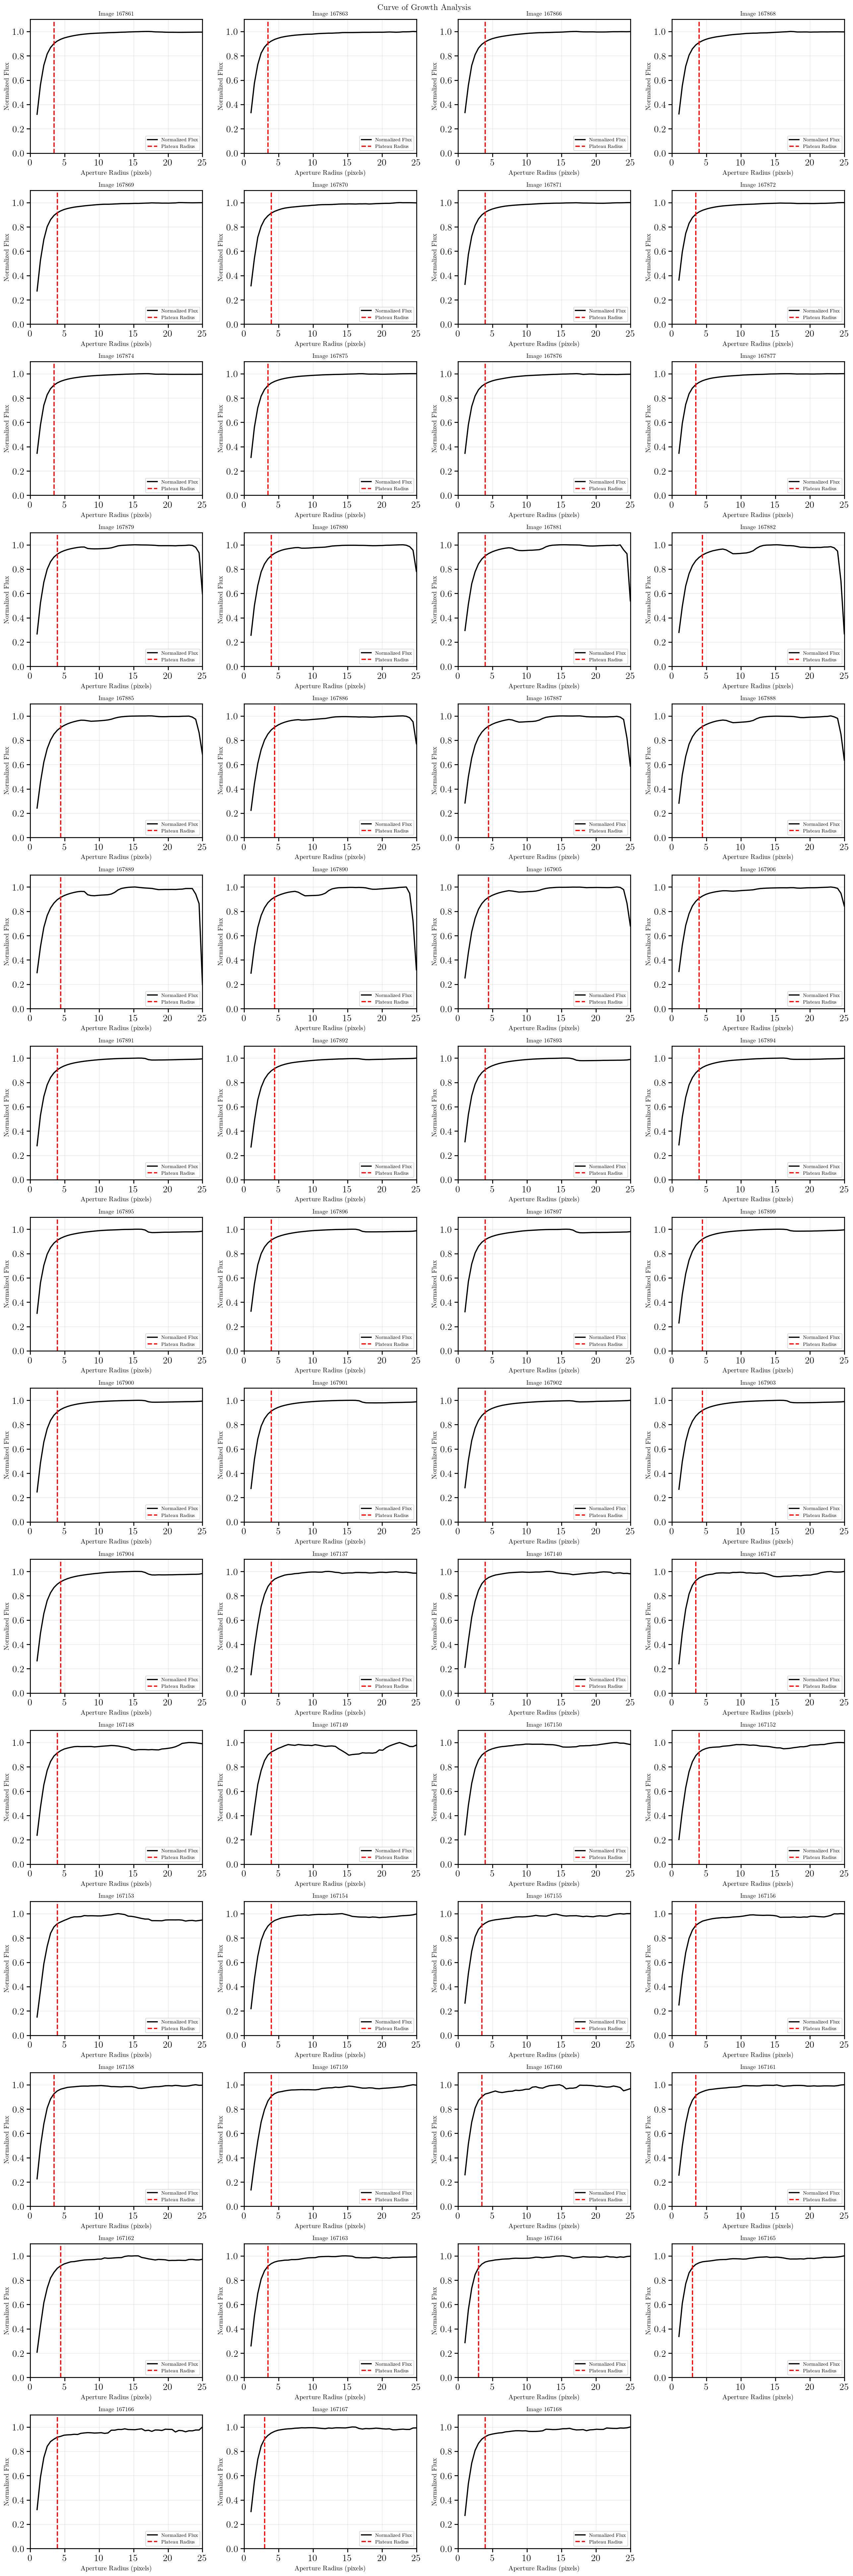

In [67]:
results = examine_curve_of_growth(
    all_codes, 
    all_dirs, 
    all_locs,
    max_radius=25
)

In [195]:
# So set the apertures and annuli

r_ap = 5  # aperture radius in pixels

an1 = np.array([1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
                1.5, 1.5, 1.5, 1.2, 1.2, 1.2,
                1.2, 1.2, 1.2, 1.1, 1.1, 1.1,
                1.1, 1.1, 1.1, 2.5, 2.4, 2.3,
                2.3, 2.3, 2.3, 2.2, 2.2, 2.2])

an2 = np.array([2.0, 2.0, 2.0, 2.0, 2.0, 2.0,
                2.0, 2.0, 2.0, 1.7, 1.7, 1.7,
                1.7, 1.7, 1.7, 1.6, 1.6, 1.6,
                1.6, 1.6, 1.6, 3.0, 2.9, 2.8,
                2.8, 2.8, 2.8, 2.7, 2.7, 2.7])

custom_annuli_asteroid = {
    'inner': an1,
    'outer': an2
}


## Perform Photometry

In [196]:
def perform_photometry(codes, data, locations, r_ap, data_dir, object_name="object", 
                       custom_annuli=None):
    """
    Perform aperture photometry on all images.
    
    Parameters:
    -----------
    codes : list
        Image codes
    data : list
        Image data arrays
    locations : list
        Source pixel coordinates
    r_ap : float or list
        Aperture radius (or list of radii if different for each image)
    data_dir : str or dict
        Directory or dict of directories containing FITS files
    object_name : str
        Name of object for display
    custom_annuli : dict, optional
        Dictionary with 'inner' and 'outer' keys containing arrays of sky annulus 
        multipliers for each image. Example:
        {'inner': np.array([1.5, 1.5, ...]), 'outer': np.array([2.0, 2.0, ...])}
        Each value is multiplied by r_ap to get actual radius.
    
    Returns:
    --------
    dict : Photometry results keyed by image code
    """
    results = {}
    
    # Convert r_ap to list if needed
    if not isinstance(r_ap, (list, np.ndarray)):
        r_ap_list = [r_ap] * len(codes)
    else:
        r_ap_list = r_ap
    
    for i, c in enumerate(codes):
        # Determine data directory
        if isinstance(data_dir, dict):
            dir_path = data_dir.get(c, data_dir['default'])
        else:
            dir_path = data_dir
        
        # Load image
        with fits.open(f'{dir_path}/{c}.fits') as file:
            hdr = file[0].header.copy()
            image = file[0].data
        
        # Get aperture radius for this image
        current_r_ap = r_ap_list[i]
        
        # Define sky annulus radii
        if custom_annuli is not None:
            # Use custom annuli if provided
            r_sky_in = custom_annuli['inner'][i] * current_r_ap
            r_sky_out = custom_annuli['outer'][i] * current_r_ap
        else:
            # Use default annuli
            r_sky_in = current_r_ap * 1.5
            r_sky_out = current_r_ap * 2
        
        ap = CircularAperture(locations[i], r=current_r_ap)
        an = CircularAnnulus(locations[i], r_in=r_sky_in, r_out=r_sky_out)
        
        # Sky background
        sky_phot = aperture_photometry(image, an)
        sky_area = np.pi * (r_sky_out**2 - r_sky_in**2)
        sky_flux = sky_phot['aperture_sum'].value
        mean_sky = sky_flux / sky_area
        
        # Source photometry
        src_phot = aperture_photometry(image - mean_sky, ap)
        src_flux = src_phot['aperture_sum'].value
        
        # Calculate magnitude
        exposure = hdr['EXPOSURE']
        norm_flux = src_flux / exposure
        magnitude = flux_to_mag(norm_flux)
        mag_error = error_in_mag(src_flux, sky_flux)
        
        # Get filter and airmass
        filt = normalize_filter_name(hdr.get('FILTER', 'UNKNOWN'), filter_map)
        airmass = get_airmass(hdr)
        
        # Store results
        results[c] = {
            'magnitude': magnitude,
            'error': mag_error,
            'filter': filt,
            'airmass': airmass,
            'exposure': exposure,
            'flux': src_flux,
            'norm_flux': norm_flux
        }
        
        print(f'{object_name} image {c}: mag = {magnitude[0]:.4f} +/- {abs(mag_error[0]):.4f}, '
              f'filter = {filt}, airmass = {airmass:.3f}')
    
    return results

In [197]:
print("=" * 60)
print("STANDARD STAR 1 PHOTOMETRY")
print("=" * 60)
ss1_results = perform_photometry(
    codes1, data1, locs1, r_ap,
    f'{direc}/Reduced_data_day3',
    object_name="SS1"
)

print("\n" + "=" * 60)
print("STANDARD STAR 2 PHOTOMETRY")
print("=" * 60)
ss2_results = perform_photometry(
    codes2, data2, locs2, r_ap,
    f'{direc}/Reduced_data_day3',
    object_name="SS2"
)

print("\n" + "=" * 60)
print("STANDARD STAR 3 PHOTOMETRY")
print("=" * 60)
ss3_results = perform_photometry(
    codes3, data3, locs3, r_ap,
    f'{direc}/Reduced_data_day3',
    object_name="SS3"
)

print("\n" + "=" * 60)
print(f"{asteroid_name.upper()} PHOTOMETRY")
print("=" * 60)
asteroid_results = perform_photometry(
    asteroid_codes, data_asteroid, locs_asteroid, r_ap,
    asteroid_data_dirs,
    object_name=asteroid_name,
    custom_annuli=custom_annuli_asteroid
)

STANDARD STAR 1 PHOTOMETRY
SS1 image 167861: mag = -9.8575 +/- 0.0022, filter = R, airmass = 1.257
SS1 image 167863: mag = -8.7635 +/- 0.0036, filter = B, airmass = 1.262
SS1 image 167866: mag = -9.4230 +/- 0.0027, filter = I, airmass = 1.292
SS1 image 167868: mag = -9.4290 +/- 0.0027, filter = I, airmass = 1.307
SS1 image 167869: mag = -8.7501 +/- 0.0036, filter = B, airmass = 1.310
SS1 image 167870: mag = -8.7545 +/- 0.0036, filter = B, airmass = 1.312
SS1 image 167871: mag = -9.5364 +/- 0.0025, filter = V, airmass = 1.315
SS1 image 167872: mag = -9.5462 +/- 0.0025, filter = V, airmass = 1.317
SS1 image 167874: mag = -9.8584 +/- 0.0022, filter = R, airmass = 1.328
SS1 image 167875: mag = -9.8545 +/- 0.0022, filter = R, airmass = 1.330
SS1 image 167876: mag = -9.4293 +/- 0.0027, filter = I, airmass = 1.332
SS1 image 167877: mag = -9.5463 +/- 0.0025, filter = V, airmass = 1.335

STANDARD STAR 2 PHOTOMETRY
SS2 image 167879: mag = -9.3492 +/- 0.0027, filter = V, airmass = 1.148
SS2 image

## Calibration

Calculate extinction coefficients and zero points for each filter.

In [198]:
# Combine all SS photometry results first

merged_photometry = ss1_results | ss2_results | ss3_results


In [199]:
def calculate_extinction_and_zeropoint(results_dict, true_mags_dict):
    """
    Calculate extinction coefficient and zero point for each filter using multiple standard stars.
    
    Model: m_true = m_inst + m_zp,airmass - k*(airmass - 1)
    Rearranged: m_true - m_inst = m_zp,airmass - k*(airmass - 1)
    Or: delta_mag = -k*(airmass - 1) + ZP
    
    Uses scipy.optimize.curve_fit for robust parameter estimation and uncertainty calculation.
    
    Parameters:
    -----------
    results_dict : dict
        Dictionary mapping object names to their photometry results
        e.g., {'SS1': ss1_results, 'SS2': ss2_results, 'SS3': ss3_results}
    true_mags_dict : dict
        Dictionary mapping object names to their true magnitudes
        e.g., {'SS1': {'B': 12.223, 'V': 11.463, ...}, 'SS2': {...}, ...}
    
    Returns:
    --------
    tuple : (extinction_dict, zeropoint_dict, uncertainties_dict)
        uncertainties_dict contains {'k_err', 'zp_err', 'residual_std', 'r_squared'} for each filter
    """
    
    # Define the linear model
    def linear_model(x, slope, intercept):
        return slope * x + intercept
    
    # Organize ALL stars by filter
    by_filter = {}
    
    for obj_name, results in results_dict.items():
        true_mags = true_mags_dict[obj_name]
        
        for code, data in results.items():
            filt = data['filter']
            if filt not in by_filter:
                by_filter[filt] = {
                    'mags': [], 
                    'airmass': [], 
                    'true_mags': [], 
                    'obj_names': [],
                    'errors': []
                }
            
            # Add this observation with its corresponding true magnitude
            by_filter[filt]['mags'].append(data['magnitude'][0])
            by_filter[filt]['airmass'].append(data['airmass'])
            by_filter[filt]['true_mags'].append(true_mags[filt])
            by_filter[filt]['obj_names'].append(obj_name)
            by_filter[filt]['errors'].append(abs(data.get('error', [0])[0]))
    
    extinction = {}
    zeropoint = {}
    uncertainties = {}
    
    # Create figure
    n_filters = len(by_filter)
    fig, axes = plt.subplots(1, n_filters, figsize=(5*n_filters, 4))

    if n_filters == 1:
        axes = [axes]
    
    ax_idx = 0
    
    for filt, data in by_filter.items():
        mags = np.array(data['mags'])
        airmass = np.array(data['airmass'])
        true_mags = np.array(data['true_mags'])
        obj_names = data['obj_names']
        errors = np.array(data['errors'])

        # Model: m_true - m_inst = -k*(airmass - 1) + ZP
        # This is y = slope * x + intercept where:
        # y = m_true - m_inst (delta_mag)
        # x = (airmass - 1)
        # slope = -k (so k = -slope)
        # intercept = ZP
        
        delta_mag = true_mags - mags
        x = airmass - 1
        
        # Use measurement errors as weights if available
        # If errors are zero or very small, use uniform weights
        if np.all(errors > 0) and np.std(errors) > 1e-6:
            sigma = errors
        else:
            sigma = None  # uniform weights
        
        try:
            # Perform curve_fit
            # Initial guess: slope ~ 0, intercept ~ median(delta_mag)
            p0 = [0.0, np.median(delta_mag)]
            
            popt, pcov = curve_fit(
                linear_model, 
                x, 
                delta_mag,
                p0=p0,
                sigma=sigma,
                absolute_sigma=False  # Use relative weights
            )
            
            slope = popt[0]
            intercept = popt[1]
            
            # Extract uncertainties from covariance matrix
            perr = np.sqrt(np.diag(pcov))
            slope_err = perr[0]
            intercept_err = perr[1]
            
            # Convert to extinction coefficient and zero point
            k = -slope  # extinction coefficient
            zp = intercept  # zero point at airmass = 1
            k_err = slope_err  # uncertainty in k
            zp_err = intercept_err  # uncertainty in zero point
            
        except Exception as e:
            print(f"Warning: curve_fit failed for {filt} band: {e}")
            print("Falling back to simple linear regression")
            
            # Fallback to polyfit
            coeffs = np.polyfit(x, delta_mag, 1)
            slope = coeffs[0]
            intercept = coeffs[1]
            k = -slope
            zp = intercept
            
            # Estimate errors manually
            n = len(x)
            y_pred = slope * x + intercept
            residuals = delta_mag - y_pred
            residual_std = np.std(residuals, ddof=2)
            x_mean = np.mean(x)
            ss_x = np.sum((x - x_mean)**2)
            slope_err = residual_std / np.sqrt(ss_x)
            intercept_err = residual_std * np.sqrt(1/n + x_mean**2/ss_x)
            k_err = slope_err
            zp_err = intercept_err
        
        
        print(f"{filt} band:")
        print(f"  k = {k:.4f} ± {k_err:.4f} mag/airmass")
        print(f"  ZP = {zp:.4f} ± {zp_err:.4f} mag")
        print(f"  Used {len(mags)} observations from {len(set(obj_names))} stars")
        print()
        
        uncertainties[filt] = {
            'k_err': k_err,
            'zp_err': zp_err
        }
        
        # Plot
        ax = axes[ax_idx]
        
        # Color code by star
        colors = {'SS1': 'blue', 'SS2': 'red', 'SS3': 'green'}
        for obj in set(obj_names):
            mask = np.array(obj_names) == obj
            # Plot with error bars if available
            ax.errorbar(airmass[mask], delta_mag[mask], 
                        yerr=errors[mask] if np.any(errors[mask] > 0) else None,
                        fmt='o', label=obj, c=colors.get(obj, 'black'), 
                        markersize=6, capsize=3)
        
        # Fit line
        airmass_fit = np.linspace(airmass.min(), airmass.max(), 100)
        x_fit = airmass_fit - 1
        delta_mag_fit = slope * x_fit + intercept
        ax.plot(airmass_fit, delta_mag_fit, 'k-', linewidth=2,
                label=f'k={k:.3f}±{k_err:.3f}')
        ax.set_xlabel('Airmass', fontsize=12)
        ax.set_ylabel('$m_{true} - m_{inst}$', fontsize=12)
        ax.set_title(f'{filt} band', fontsize=14)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        
        extinction[filt] = k
        zeropoint[filt] = zp
        
        # Store covariance matrix for uncertainty ellipse plotting
        # pcov has shape (2,2) for slope and intercept
        # Convert to k and ZP: since k = -slope, we need to adjust signs
        pcov_kzp = np.array([
            [pcov[0,0], -pcov[0,1]],  # var(k), cov(k,ZP) - note k=-slope
            [-pcov[1,0], pcov[1,1]]   # cov(ZP,k), var(ZP)
        ])
        uncertainties[filt]['cov_matrix'] = pcov_kzp
        
        ax_idx += 1
    
    # Show plot AFTER all filters are processed
    plt.tight_layout()
    plt.show()
    
    return extinction, zeropoint, uncertainties

Now, we need to obtain true magnitudes in each filter.


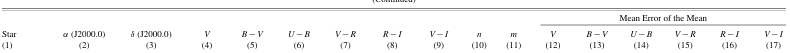

SS1: 


SS2: 


SS3:



From Landolt, Arlo U. ‘UBVRI Photometric Standard Stars around the Sky at +50 Deg Declination’. The Astronomical Journal 146 (November 2013): 131. https://doi.org/10.1088/0004-6256/146/5/131.
For each filter, we may calculate true magnitudes as:

$B = V + (B-V)$

$R = V - (V-R)$

$I = V - (V-R) - (R-I)$

EXTINCTION AND ZERO POINTS (ALL STANDARD STARS)
R band:
  k = 0.0957 ± 0.0406 mag/airmass
  ZP = 20.9155 ± 0.0143 mag
  Used 10 observations from 3 stars

B band:
  k = 0.1359 ± 0.0829 mag/airmass
  ZP = 20.9698 ± 0.0284 mag
  Used 9 observations from 3 stars

I band:
  k = 0.0030 ± 0.0404 mag/airmass
  ZP = 19.9352 ± 0.0138 mag
  Used 9 observations from 3 stars

V band:
  k = 0.1490 ± 0.0433 mag/airmass
  ZP = 21.0568 ± 0.0150 mag
  Used 9 observations from 3 stars



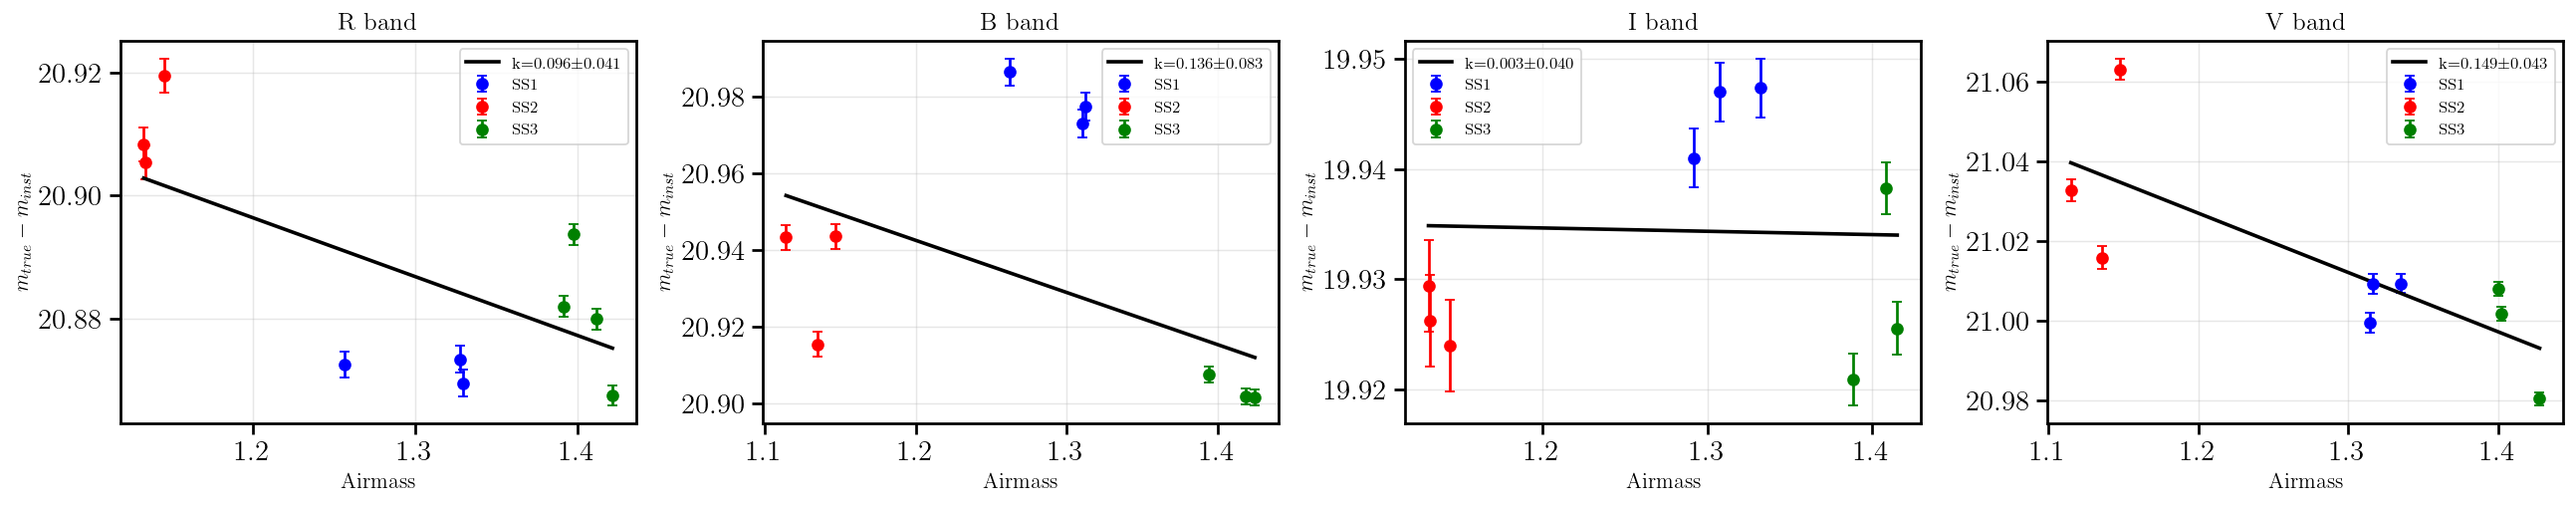

In [200]:
# True magnitudes for each star
ss1_true_mags = {'B': 12.223, 'V': 11.463, 'R': 11.015, 'I': 10.518}
ss2_true_mags = {'B': 11.981, 'V': 11.714, 'R': 11.568, 'I': 11.403}
ss3_true_mags = {'B': 11.033, 'V': 10.658, 'R': 10.456, 'I': 10.243}

# Organize results and true mags by object
results_by_object = {
    'SS1': ss1_results,
    'SS2': ss2_results,
    'SS3': ss3_results
}

true_mags_by_object = {
    'SS1': ss1_true_mags,
    'SS2': ss2_true_mags,
    'SS3': ss3_true_mags
}

print("=" * 60)
print("EXTINCTION AND ZERO POINTS (ALL STANDARD STARS)")
print("=" * 60)

extinction, zeropoints, uncertainties = calculate_extinction_and_zeropoint(
    results_by_object, 
    true_mags_by_object
)

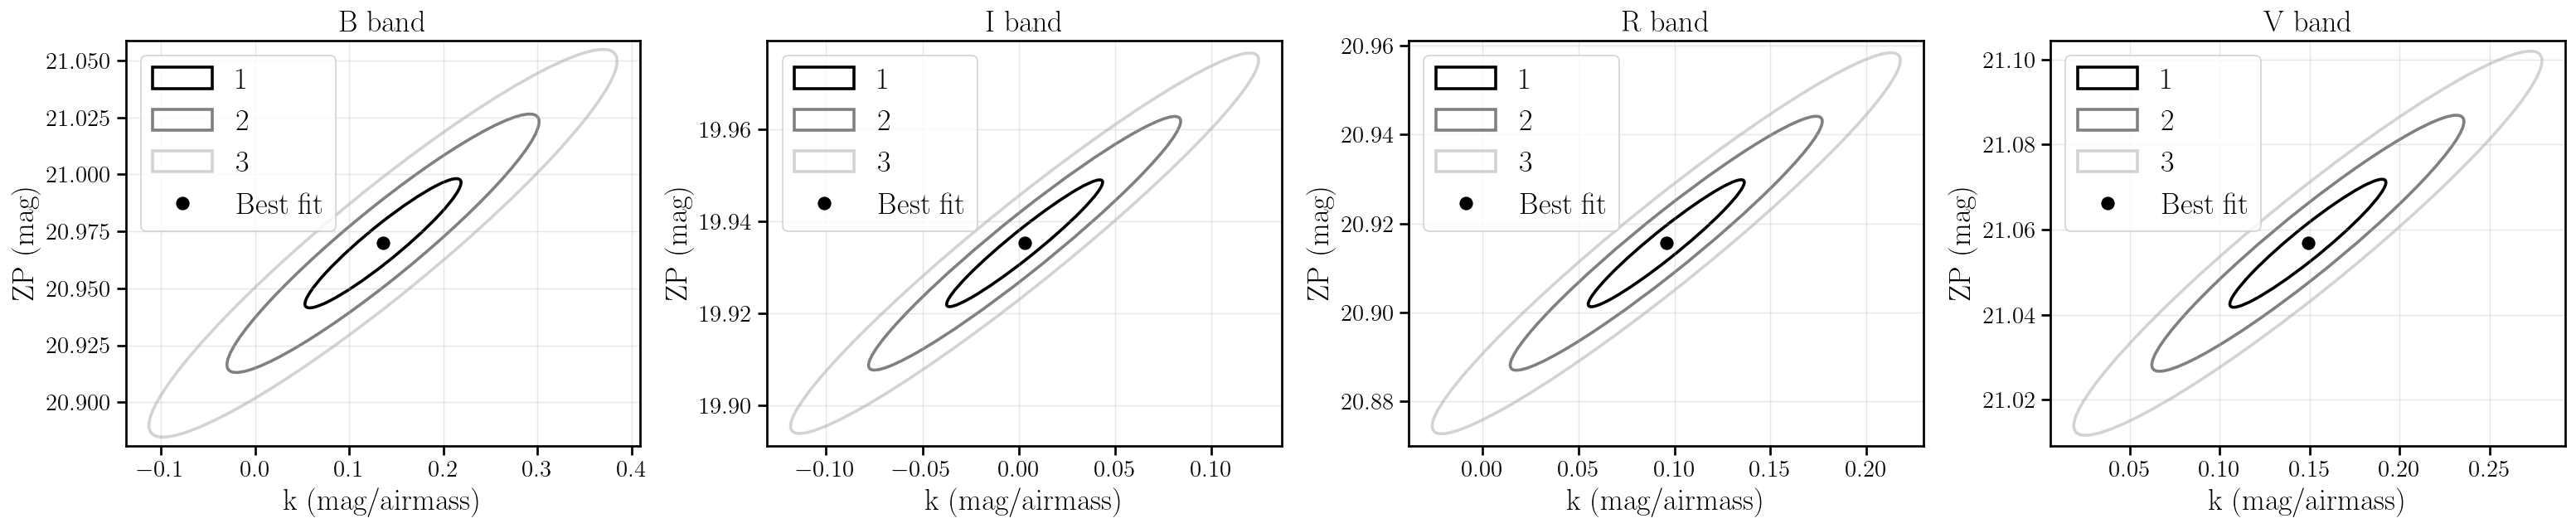

In [201]:
# Get all available filters
filters = sorted(extinction.keys())
n_filters = len(filters)

# Create subplots - one for each filter
fig, axes = plt.subplots(1, n_filters, figsize=(6*n_filters, 5))

# Handle case of single filter
if n_filters == 1:
    axes = [axes]

for idx, filt in enumerate(filters):
    # Extract parameters
    k = extinction[filt]
    zp = zeropoints[filt]
    k_err = uncertainties[filt]['k_err']
    zp_err = uncertainties[filt]['zp_err']
    cov_matrix = uncertainties[filt]['cov_matrix']
    
    # Calculate correlation coefficient
    correlation = cov_matrix[0,1] / np.sqrt(cov_matrix[0,0] * cov_matrix[1,1])
    
    ax = axes[idx]
    
    # Calculate eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    
    # Plot ellipses for 1σ, 2σ, 3σ
    colors = ['black', 'gray', 'lightgray']
    sigma_levels = [1, 2, 3]
    
    for i, n_sigma in enumerate(sigma_levels):
        width = 2 * n_sigma * np.sqrt(eigenvalues[0])
        height = 2 * n_sigma * np.sqrt(eigenvalues[1])
        
        ellipse = Ellipse(xy=(k, zp),
                         width=width,
                         height=height,
                         angle=angle,
                         facecolor='none',
                         edgecolor=colors[i],
                         linewidth=2,
                         label=f'{n_sigma}')
        ax.add_patch(ellipse)
    
    # Plot best-fit point
    ax.plot(k, zp, 'ko', markersize=8, label='Best fit', zorder=5)
    
    # Set axis limits
    max_sigma = 3
    margin_x = max_sigma * np.sqrt(eigenvalues[0]) * 1.3
    margin_y = max_sigma * np.sqrt(eigenvalues[1]) * 1.3
    
    #ax.set_xlim(k - margin_x, k + margin_x)
    #ax.set_ylim(zp - margin_y, zp + margin_y)
    
    # Labels and formatting - using simple text instead of LaTeX
    ax.set_xlabel(f'k (mag/airmass)')
    ax.set_ylabel(f'ZP (mag)')
    ax.set_title(f'{filt} band')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()


Instead of doing it for each star separately, do for all of them within the same band and then calculate the extinction coefficient. 

## Apply calibration to find true colours of Belgica

In [202]:
def apply_calibration(results, combined_extinction, combined_zeropoints, uncertainties, object_name="Object"):
    """
    Apply extinction correction and zero points to get calibrated magnitudes with uncertainties.
    
    Model: m_true = m_inst - k*(X - 1) - ZP
    
    Uncertainty propagation:
    σ²(m_true) = σ²(m_inst) + (X-1)²·σ²(k) + σ²(ZP) + k²·σ²(X)
    
    Parameters:
    -----------
    results : dict
        Photometry results from asteroid (must contain 'magnitude', 'error', 'airmass', 'filter')
    combined_extinction : dict
        Extinction coefficients per filter
    combined_zeropoints : dict
        Zero points per filter
    uncertainties : dict
        Dictionary containing 'k_err' and 'zp_err' for each filter
    object_name : str
        Name of object for printing
    
    Returns:
    --------
    tuple : (calibrated_mags, calibrated_mags_err)
        calibrated_mags: dict of mean calibrated magnitude per filter
        calibrated_mags_err: dict of uncertainty in mean magnitude per filter
    """
    # Organize by filter
    by_filter = {}
    for code, data in results.items():
        filt = data['filter']
        if filt not in by_filter:
            by_filter[filt] = {
                'cal_mags': [],
                'cal_errs': []
            }
        
        inst_mag = data['magnitude'][0]
        inst_err = abs(data['error'][0])
        airmass = data['airmass']
        
        # Apply extinction correction and zero point
        # m_true = m_inst - k*(X - 1) - ZP
        if filt in combined_extinction and filt in combined_zeropoints:
            k = combined_extinction[filt]
            zp = combined_zeropoints[filt]
            k_err = uncertainties[filt]['k_err']
            zp_err = uncertainties[filt]['zp_err']
            
            # Calculate calibrated magnitude
            cal_mag = inst_mag - k * (airmass - 1) - zp
            
            # Propagate uncertainties
            sigma_X = 0.001  # airmass uncertainty (negligible)
            cal_err = np.sqrt(
                inst_err**2 + 
                ((airmass - 1) * k_err)**2 + 
                zp_err**2 + 
                (k * sigma_X)**2
            )
            
            by_filter[filt]['cal_mags'].append(cal_mag)
            by_filter[filt]['cal_errs'].append(cal_err)
    
    # Calculate mean magnitudes per filter
    calibrated_mags = {}
    calibrated_mags_err = {}
    
    print(f"\n{object_name} Calibrated Magnitudes:")
    for filt in sorted(by_filter.keys()):
        cal_mags = np.array(by_filter[filt]['cal_mags'])
        cal_errs = np.array(by_filter[filt]['cal_errs'])
        
        # Weighted mean
        weights = 1.0 / cal_errs**2
        mean_mag = np.sum(cal_mags * weights) / np.sum(weights)
        mean_err = np.sqrt(1.0 / np.sum(weights))
        
        calibrated_mags[filt] = mean_mag
        calibrated_mags_err[filt] = mean_err
        
        print(f"  {filt}: {mean_mag:.4f} ± {mean_err:.4f} (from {len(cal_mags)} observations)")
    
    return calibrated_mags, calibrated_mags_err


asteroid_calibrated_mags, asteroid_calibrated_mags_err = apply_calibration(asteroid_results, 
    extinction, 
    zeropoints,
    uncertainties,
    object_name=asteroid_name)

# Now calculate colors and the corresponding errors 
# Combine errors by adding them in quadrature

print(f"\n{asteroid_name} Colors:")
if 'B' in asteroid_calibrated_mags and 'V' in asteroid_calibrated_mags:
    bv = asteroid_calibrated_mags['B'] - asteroid_calibrated_mags['V']
    bv_err = np.sqrt((asteroid_calibrated_mags_err['B'])**2 + (asteroid_calibrated_mags_err['V'])**2)
    print(f"  B-V: {bv:.4f} +/- {bv_err:.4f}")

if 'V' in asteroid_calibrated_mags and 'R' in asteroid_calibrated_mags:
    vr = asteroid_calibrated_mags['V'] - asteroid_calibrated_mags['R']
    vr_err = np.sqrt((asteroid_calibrated_mags_err['V'])**2 + (asteroid_calibrated_mags_err['R'])**2)
    print(f"  V-R: {vr:.4f} +/- {vr_err:.4f}")

if 'R' in asteroid_calibrated_mags and 'I' in asteroid_calibrated_mags:
    ri = asteroid_calibrated_mags['R'] - asteroid_calibrated_mags['I']
    ri_err = np.sqrt((asteroid_calibrated_mags_err['R'])**2 + (asteroid_calibrated_mags_err['I'])**2)
    print(f"  R-I: {ri:.4f} +/- {ri_err:.4f}")

if 'V' in asteroid_calibrated_mags and 'I' in asteroid_calibrated_mags:
    vi = asteroid_calibrated_mags['V'] - asteroid_calibrated_mags['I']
    vi_err = np.sqrt((asteroid_calibrated_mags_err['V'])**2 + (asteroid_calibrated_mags_err['I'])**2)
    print(f"  V-I: {vi:.4f} +/- {vi_err:.4f}")


Belgica Calibrated Magnitudes:
  B: -26.3419 ± 0.0248 (from 3 observations)
  I: -26.0585 ± 0.0124 (from 3 observations)
  R: -27.5976 ± 0.0060 (from 13 observations)
  V: -27.3769 ± 0.0132 (from 3 observations)

Belgica Colors:
  B-V: 1.0349 +/- 0.0281
  V-R: 0.2208 +/- 0.0145
  R-I: -1.5391 +/- 0.0138
  V-I: -1.3183 +/- 0.0181


V band:
  k = 0.1997 ± 0.0749 mag/airmass
  ZP = 21.0987 ± 0.0287 mag
  Used 4 observations from 4 stars



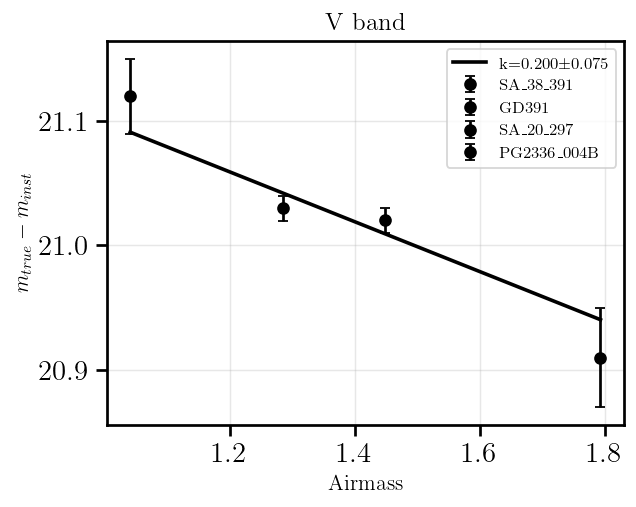


V band:
  Extinction coefficient (k): 0.1997 +/- 0.0749 mag/airmass
  Zero point (ZP):            21.0987 +/- 0.0287 mag

PG2336_004B Calibrated Magnitudes:
  V: -29.7371 ± 0.0771 (from 1 observations)

Expected V magnitude: 12.4300
Calibrated V magnitude: -29.7371 ± 0.0771
Difference: 42.1671 mag


In [203]:
# I might be a bit lost so let me just test with the test data real quick 

test_star_data = {
    'PG2336_004B': {
        'v_mag': 12.43,
        'altitude': 33.9,  # degrees
        'exp_time': 30.0,  # seconds
        'counts': 73980,
        'counts_error': 2714
    },
    'GD391': {
        'v_mag': 13.38,
        'altitude': 74.2,
        'exp_time': 60.0,
        'counts': 74820,
        'counts_error': 2059
    },
    'SA_38_391': {
        'v_mag': 8.58,
        'altitude': 51.1,
        'exp_time': 10.0,
        'counts': 954928,
        'counts_error': 8702
    },
    'SA_20_297': {
        'v_mag': 8.91,
        'altitude': 43.7,
        'exp_time': 15.0,
        'counts': 1047480,
        'counts_error': 9620
    }
}

test_results_dict = {}
test_true_mags_dict = {}

for star_name, data in test_star_data.items():
    # Calculate instrumental magnitude
    norm_flux = data['counts'] / data['exp_time']
    inst_mag = flux_to_mag(np.array([norm_flux]))[0]
    
    # Calculate magnitude error
    mag_error = error_in_mag(
        np.array([data['counts']]), 
        np.array([data['counts_error']**2])
    )[0]
    
    # Calculate airmass from altitude
    altitude_rad = np.radians(data['altitude'])
    airmass = 1.0 / np.sin(altitude_rad)
    
    # Format for results_dict (using 'V_1' as the observation code)
    test_results_dict[star_name] = {
        'V_1': {
            'filter': 'V',
            'magnitude': [inst_mag],
            'error': [mag_error],
            'airmass': airmass
        }
    }
    
    # Format for true_mags_dict
    test_true_mags_dict[star_name] = {
        'V': data['v_mag']
    }

extinction, zeropoints, uncertainties = calculate_extinction_and_zeropoint(
    test_results_dict, 
    test_true_mags_dict
)


for filt in extinction.keys():
    print(f"\n{filt} band:")
    print(f"  Extinction coefficient (k): {extinction[filt]:.4f} +/- {uncertainties[filt]['k_err']:.4f} mag/airmass")
    print(f"  Zero point (ZP):            {zeropoints[filt]:.4f} +/- {uncertainties[filt]['zp_err']:.4f} mag")


# Use PG2336_004B as test object
test_object_name = 'PG2336_004B'
test_object_results = test_results_dict[test_object_name]
expected_mag = test_true_mags_dict[test_object_name]['V']

calibrated_mags, calibrated_mags_err = apply_calibration(
    test_object_results,
    extinction,
    zeropoints,
    uncertainties,
    object_name=test_object_name
)

print(f"\nExpected V magnitude: {expected_mag:.4f}")
print(f"Calibrated V magnitude: {calibrated_mags['V']:.4f} ± {calibrated_mags_err['V']:.4f}")
print(f"Difference: {abs(calibrated_mags['V'] - expected_mag):.4f} mag")

This looks okay, so our data is just BAD

## Now, let's get the size

### Calculate the ugriz colours + errors

In [204]:
def calculate_sdss_colors(bv, vr, ri):
    """
    Convert Johnson-Cousins colors to SDSS colors.
    
    Parameters:
    -----------
    bv : float
        B-V color
    vr : float
        V-R color
    ri : float
        R-I color
    
    Returns:
    --------
    dict : SDSS colors (g-r, r-i, r-z)
    """
    # Equation (2): g - r = 0.278(+/- 0.016) * (B-V) + 1.321(+/- 0.030) * (V-R) - 0.219
    g_minus_r = (0.278 * bv) + (1.321 * vr) - 0.219
    
    # Equation (3): r - i = 1.070(+/- 0.009) * (R-I) - 0.228
    r_minus_i = (1.070 * ri) - 0.228
    
    # Equation (4): r - z = 1.607(+/- 0.012) * (R-I) - 0.371
    r_minus_z = (1.607 * ri) - 0.371

    i_minus_z = r_minus_z - r_minus_i
    
    return {
        'g-r': g_minus_r,
        'r-i': r_minus_i,
        'r-z': r_minus_z,
        'i-z': i_minus_z
    }

def calculate_sdss_colors_with_errors(bv, vr, ri, bv_err, vr_err, ri_err):
    """
    Convert Johnson-Cousins colors to SDSS colors with error propagation.
    
    Parameters:
    -----------
    bv, vr, ri : float
        B-V, V-R, R-I colors
    bv_err, vr_err, ri_err : float
        Uncertainties in colors
    
    Returns:
    --------
    dict : SDSS colors with errors
    """
    colors = calculate_sdss_colors(bv, vr, ri)
    
    # Error propagation (assuming independent uncertainties)
    # For g-r: sig^2 = (0.278*sig_BV)^2 + (1.321*sig_VR)^2 + sig_cal^2 where sig_cal includes calibration errors 
    # These are the +/- values given in the table
    gr_err = np.sqrt((0.278 * bv_err)**2 + (1.321 * vr_err)**2 + 0.016**2 + 0.030**2)
    
    # For r-i: sig^2 = (1.070*sig_RI)^2 + sig_cal^2
    ri_err_sdss = np.sqrt((1.070 * ri_err)**2 + 0.009**2)
    
    # For r-z: sig^2 = (1.607*sig_RI)^2 + sig_cal^2
    rz_err = np.sqrt((1.607 * ri_err)**2 + 0.012**2)

    # For i-z : combine errors from r-i and r-z
    iz_err = np.sqrt(ri_err_sdss**2 + rz_err**2)
    
    return {
        'g-r': (colors['g-r'], gr_err),
        'r-i': (colors['r-i'], ri_err_sdss),
        'r-z': (colors['r-z'], rz_err),
        'i-z': (colors['i-z'], iz_err)
    }

# Calculate SDSS colors for Belgica
print("\n" + "=" * 60)
print("SDSS COLOR TRANSFORMATIONS")
print("=" * 60)
sdss_colors = calculate_sdss_colors_with_errors(bv, vr, ri, bv_err, vr_err, ri_err)

print(f"\nBelgica SDSS colors:")
for color, (value, error) in sdss_colors.items():
    print(f"  {color}: {value:.4f} +/- {error:.4f}")



SDSS COLOR TRANSFORMATIONS

Belgica SDSS colors:
  g-r: 0.3603 +/- 0.0398
  r-i: -1.8748 +/- 0.0173
  r-z: -2.8443 +/- 0.0252
  i-z: -0.9695 +/- 0.0306


### Find the spectral type based on the table below 

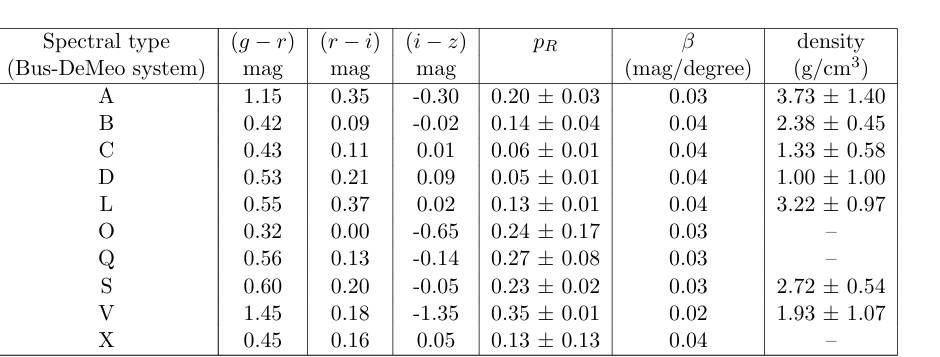

In [206]:
print("\n" + "=" * 60)
print("SPECTRAL TYPE CLASSIFICATION")
print("=" * 60)

# Reference spectral type colors from the table above
spectral_types = {
    'A': {'g-r': 1.15, 'r-i': 0.35, 'i-z': -0.30, 'pR': 0.20, 'pR_err': 0.03, 'beta': 0.03, 'density': 3.73, 'density_err': 1.40},
    'B': {'g-r': 0.42, 'r-i': 0.09, 'i-z': -0.02, 'pR': 0.14, 'pR_err': 0.04, 'beta': 0.04, 'density': 2.38, 'density_err': 0.45},
    'C': {'g-r': 0.43, 'r-i': 0.11, 'i-z': 0.01, 'pR': 0.06, 'pR_err': 0.01, 'beta': 0.04, 'density': 1.33, 'density_err': 0.58},
    'D': {'g-r': 0.53, 'r-i': 0.21, 'i-z': 0.09, 'pR': 0.05, 'pR_err': 0.01, 'beta': 0.04, 'density': 1.00, 'density_err': 1.00},
    'L': {'g-r': 0.55, 'r-i': 0.37, 'i-z': 0.02, 'pR': 0.13, 'pR_err': 0.01, 'beta': 0.04, 'density': 3.22, 'density_err': 0.97},
    'O': {'g-r': 0.32, 'r-i': 0.00, 'i-z': -0.65, 'pR': 0.24, 'pR_err': 0.17, 'beta': 0.03, 'density': None},
    'Q': {'g-r': 0.56, 'r-i': 0.13, 'i-z': -0.14, 'pR': 0.27, 'pR_err': 0.08, 'beta': 0.03, 'density': None},
    'S': {'g-r': 0.60, 'r-i': 0.20, 'i-z': -0.05, 'pR': 0.23, 'pR_err': 0.02, 'beta': 0.03, 'density': 2.72, 'density_err': 0.54},
    'V': {'g-r': 1.45, 'r-i': 0.18, 'i-z': -1.35, 'pR': 0.35, 'pR_err': 0.01, 'beta': 0.02, 'density': 1.93, 'density_err': 1.07},
    'X': {'g-r': 0.45, 'r-i': 0.16, 'i-z': 0.05, 'pR': 0.13, 'pR_err': 0.13, 'beta': 0.04, 'density': None},
}

def classify_spectral_type(measured_colors, spectral_types):
    """
    Classify asteroid spectral type based on measured SDSS colors.
    Uses Euclidean distance in color space (weighted by available colors).
    
    Parameters:
    -----------
    measured_colors : dict
        Dictionary with 'g-r', 'r-i', 'r-z' (or 'i-z') values
    spectral_types : dict
        Reference spectral type data
    
    Returns:
    --------
    best_type : str
        Best matching spectral type
    distances : dict
        Distance to each spectral type
    """
    
    distances = {}
    for spec_type, ref_colors in spectral_types.items():
        # Calculate Euclidean distance in color space
        dist_sq = 0
        count = 0
        
        for color in ['g-r', 'r-i', 'i-z']:
            if color in measured_colors:
                meas_val = measured_colors[color][0]
                ref_val = ref_colors[color]
                dist_sq += (meas_val - ref_val)**2
                count += 1
        
        if count > 0:
            distances[spec_type] = np.sqrt(dist_sq / count)
        else:
            distances[spec_type] = np.inf
    
    best_type = min(distances, key=distances.get)
    return best_type, distances

# Classify the asteroid
best_type, distances = classify_spectral_type(sdss_colors, spectral_types)

print(f"\nMeasured SDSS colors for Belgica:")
for color, (value, error) in sdss_colors.items():
    print(f"  {color}: {value:.3f} +/- {error:.3f}")

print(f"\nSpectral type distances:")
sorted_types = sorted(distances.items(), key=lambda x: x[1])
for spec_type, dist in sorted_types:  # Show top 5 matches
    print(f"  {spec_type}: {dist:.4f}")

print(f"\n{'*' * 60}")
print(f"BEST MATCH: Type {best_type}")
print(f"{'*' * 60}")

selected_properties = spectral_types[best_type]


SPECTRAL TYPE CLASSIFICATION

Measured SDSS colors for Belgica:
  g-r: 0.360 +/- 0.040
  r-i: -1.875 +/- 0.017
  r-z: -2.844 +/- 0.025
  i-z: -0.969 +/- 0.031

Spectral type distances:
  O: 1.0983
  Q: 1.2579
  B: 1.2604
  C: 1.2785
  X: 1.3150
  S: 1.3175
  D: 1.3537
  V: 1.3607
  A: 1.4168
  L: 1.4206

************************************************************
BEST MATCH: Type O
************************************************************


### Calculate the size

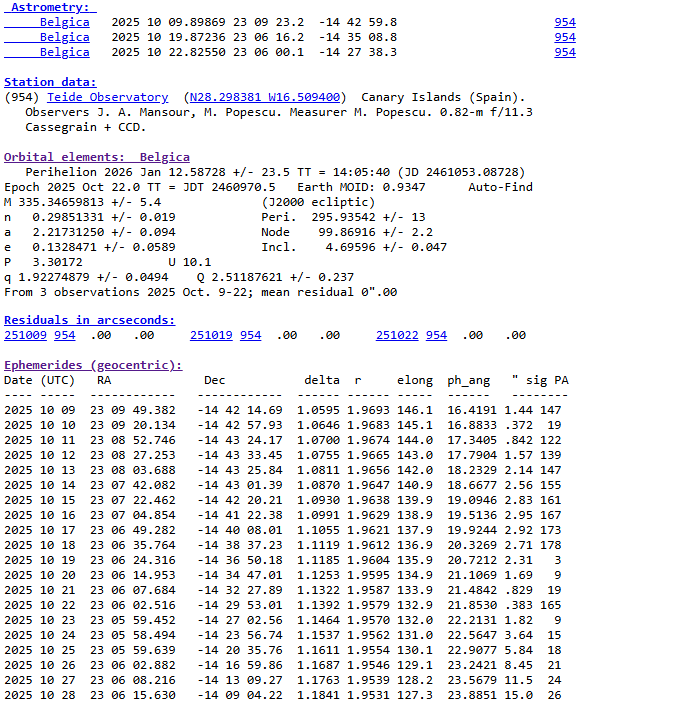

In [194]:
print("ASTEROID SIZE CALCULATION")

# FOR THE MIDDLE OBSERVATION AS ABOVE
# MIGHT NEED TO TRY THE OTHERS? 
# DO I NEED TO TRY THE OTHERS?
delta = 1.0595  # Distance from Earth to asteroid (AU)
Rh = 1.9683     # Distance from Sun to asteroid (AU)
alpha = 16.4191  # Phase angle (degrees)
print(f"\nOrbit parameters (from fit_orb):")
print(f"  Earth-asteroid distance (delta): {delta:.4f} AU")
print(f"  Sun-asteroid distance (Rh): {Rh:.4f} AU")
print(f"  Phase angle (alpha): {alpha:.2f}°")

# Convert R magnitude to mR
# You already have V magnitude, need to convert to R magnitude
# Typical V-R for asteroids is ~0.4-0.5, or use your measured V-R color

mR = asteroid_calibrated_mags['V'] + vr  # R magnitude = V magnitude + (V-R) color
mR_err = np.sqrt(asteroid_calibrated_mags_err['V']**2 + vr_err**2)

print(f"\nPhotometry:")
print(f"  V magnitude: {asteroid_calibrated_mags['V']:.3f} +/- {asteroid_calibrated_mags_err['V']:.3f}")
print(f"  V-R color: {vr:.3f}")
print(f"  R magnitude (mR): {mR:.3f} +/- {mR_err:.3f}")

# Use the properties from the table from spectral classification
pR = selected_properties['pR']
pR_err = selected_properties['pR_err']
beta = selected_properties['beta']

print(f"\nSpectral type {best_type} parameters:")
print(f"  Albedo (pR): {pR:.3f} +/- {pR_err:.3f}")
print(f"  Phase coefficient (β): {beta:.3f} mag/deg")

# Calculate asteroid radius using Equation 1 from the notes
m_sun = -27.09  # Apparent magnitude of the Sun in R band

exponent = 0.4 * (m_sun - mR + beta * alpha)
rhs = 2.238e22 * Rh**2 * delta**2 * 10**exponent

# Solve for radius r (in meters)
r_squared = rhs / pR
r_meters = np.sqrt(r_squared)
r_km = r_meters / 1000

print(f"ASTEROID RADIUS CALCULATION")
print(f"\nRadius: {r_meters:.2e} meters")
print(f"Radius: {r_km:.2f} km")
print(f"Diameter: {2*r_km:.2f} km")

# Error propagation
rel_err_albedo = pR_err / pR
rel_err_mag = 0.4 * np.log(10) * mR_err
rel_err_total = 0.5 * np.sqrt(rel_err_albedo**2 + rel_err_mag**2)
r_km_err = r_km * rel_err_total

print(f"\nWith uncertainties:")
print(f"Diameter: {2*r_km:.2f} +/- {2*r_km_err:.2f} km")

print(f"ASTEROID MASS CALCULATION")

density = selected_properties['density']  # g/cm³
density_err = selected_properties['density_err']

# Volume of sphere (assuming it's a sphere lol)
volume_m3 = (4/3) * np.pi * r_meters**3
volume_km3 = volume_m3 / 1e9

# Convert density in kg/m-3
density_kg_m3 = density * 1000
density_err_kg_m3 = density_err * 1000

# Calculate mass
mass_kg = density_kg_m3 * volume_m3
mass_metric_tons = mass_kg / 1000

print(f"\nVolume: {volume_km3:.2f} km3")
print(f"Assumed density: {density:.2f} +/- {density_err:.2f} g/cm3")
print(f"Mass: {mass_kg:.2e} kg")
print(f"Mass: {mass_metric_tons:.2e} metric tons")

# Error propagation for mass
rel_err_mass = np.sqrt((density_err/density)**2 + (3*rel_err_total)**2)
mass_kg_err = mass_kg * rel_err_mass

print(f"\nWith uncertainties:")
print(f"Mass: ({mass_kg:.2e} +/- {mass_kg_err:.2e}) kg")

print(f"\n{'*' * 60}")
print(f"SUMMARY OF RESULTS FOR BELGICA")
print(f"{'*' * 60}")
print(f"\nSpectral classification: Type {best_type}")
print(f"Diameter: {2*r_km:.2f} +/- {2*r_km_err:.2f} km")
if selected_properties['density'] is not None:
    print(f"Estimated mass: ({mass_kg:.2e} +/- {mass_kg_err:.2e}) kg")
print(f"Geometric albedo: {pR:.3f} +/- {pR_err:.3f}")


ASTEROID SIZE CALCULATION

Orbit parameters (from fit_orb):
  Earth-asteroid distance (delta): 1.0595 AU
  Sun-asteroid distance (Rh): 1.9683 AU
  Phase angle (alpha): 16.42°

Photometry:
  V magnitude: -27.465 +/- 0.014
  V-R color: 0.217
  R magnitude (mR): -27.247 +/- 0.022

Spectral type O parameters:
  Albedo (pR): 0.240 +/- 0.170
  Phase coefficient (β): 0.030 mag/deg
ASTEROID RADIUS CALCULATION

Radius: 8.59e+11 meters
Radius: 859053988.38 km
Diameter: 1718107976.77 km

With uncertainties:
Diameter: 1718107976.77 +/- 608738983.20 km
ASTEROID MASS CALCULATION


KeyError: 'density_err'

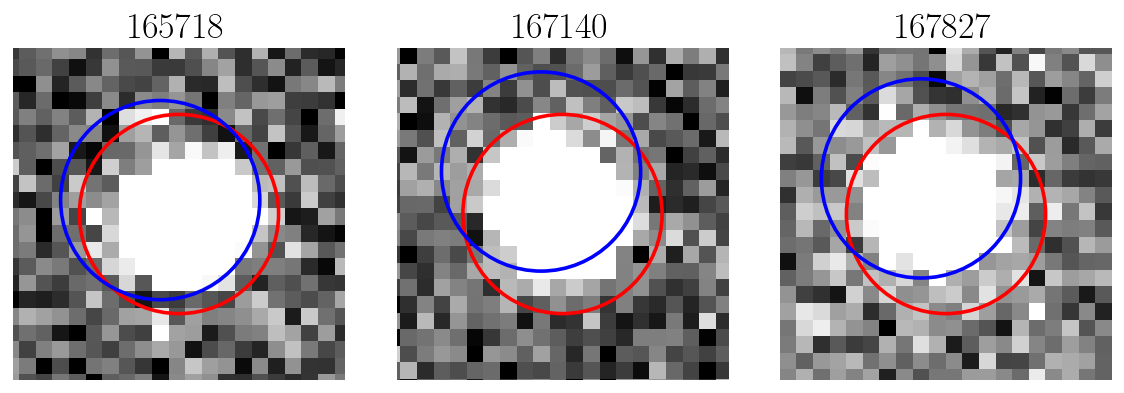

165718: (1054.1315591147284, 964.1628916470144)
167140: (1017.2904338374592, 959.4396658054812)
167827: (1027.5078438181463, 957.8554549306134)


In [26]:
# Ignore, just trying to get better coords for my astrometry 

asteroid_codes_three = [165718, 167140, 167827]


asteroid_data_dirs_three = {
    'default': f'{direc}/Reduced_data_day2',
    165718: f'{direc}/Reduced_data_day1',
    167140: f'{direc}/Reduced_data_day2',
    167827: f'{direc}/Reduced_data_day3'
}


data_asteroid_three, locs_asteroid_three, hdrs_asteroid_three = find_asteroid_locations(
    asteroid_codes_three, 
    asteroid_name, 
    observatory_code,
    asteroid_data_dirs_three,
    centroid_radius=10,
    visualize=True
)

for i in range(len(asteroid_codes_three)):
    print(f'{asteroid_codes_three[i]}: {locs_asteroid_three[i]}')